# Population dymanics response to parameters variation

The ODE system for tha population dynamics model is

\begin{equation}
\begin{aligned}
    \dot{n}_5
    &=
    \sigma P F(t)\, n_4
    - W_{51} n_1 n_5
    - W_{52} n_2 n_5
    - k_{54} n_5 
    \\
     \dot{n}_4
    &= -\dot{n_5} 
    \\
    \dot{n}_3
    &=
    W_{52} n_2 n_5
    - k_{31} n_3 
    \\
    \dot{n}_2
    &=
    W_{51} n_1 n_5
    - W_{52} n_2 n_5
    - k_{21} n_2 \\
    \dot{n}_1 &= -(\dot{n}_2 + \dot{n}_3)    
\end{aligned} .
\end{equation}

We rescaled the populations in terms of the initial populations of the ground state $n_0 = n_1(0) + n_4(0)$. The time was rescaled by $\tau = 1/f$ and the rescaled ODE system is as follows:

\begin{aligned}
\dot{x_5}(\tau)
&=
\Pi F(\tau) x_4
- W'_{51} x_1 x_5
- W'_{52} x_2 x_5
- k'_{54} x_5
\\
\dot{x_4}(\tau)
&= - \dot{x_5}
\\
\dot{x_3}(\tau)
&=
W'_{52} x_2 x_5
- k'_{31} x_3 \\
\dot{x_2}(\tau)
&=
W'_{51} x_5
- W'_{52} x_2 x_5
- k'_{21} x_2
\\
\dot{x_1}(\tau)
&= -(\dot{x_3} + \dot{x_2})
\end{aligned},

where the rescaled radiative trasition rates are defined as $k'_{ji} = k_{ji}/f$ and the non-radiative transition rates are $W'_{ji} = W_{ji}n_0/f$.



#### Preamble and experimental data

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from random import random
import os

# from treament_tcspc_data import fetch_data_filenames, extract_data_info_from_path, time_domain_visual_verification
from snr_aux_functions import plot_time_and_freq_domain

In [2]:
# Phase difference list, processed previously
pd_list = np.load("./phase_difference_list.npy")

In [3]:
#--------------------------------------
# Estimations of n1 and n4
#--------------------------------------
dens_y2o3 = 5.010 #g/cm^3
massa_molar_y2o3 = 225.81 #g/mol
frac_er = 0.005 # Er3+ percentage in the sample
frac_yb = 0.015 # Yb3+ percentage in the sample

n1_0 = (dens_y2o3/massa_molar_y2o3)*(6.022e23)*2*(frac_er) # number of Er3+ ions 
n4_0 = (dens_y2o3/massa_molar_y2o3)*(6.022e23)*2*(frac_yb) # number of Yb3+ ions

n0 = n1_0 + n4_0

In [4]:
#--------------------------------------
# Parameters
#--------------------------------------
k21 = 16.66   # s^-1, Tab. 2 em https://doi.org/10.1063/1.2739301
k31 = 17237.7 # s^-1
k54 = 1279.0  # Tab. 2 Lu0 em https://doi.org/10.1016/j.jallcom.2021.159227
sigma = 1.75e-20 # # Supporting Information, page S5, Labrador

P = 1e23 #The estimated value from experiment is 1e24 #Photons/(cm³ * s)
# P = 1e20#5.4e20    # photons / (cm^2 * s) (The value based on Labrador paper is for 110 W/cm^2  )

#====================================================
# Some constants
#====================================================
# ww51 = 1e-10#8.192933479247868e-09 # chute incial
# ww52 = 1e-10#1.9970817793515877e-07 # chute inicial
ww51 = 1.0e-11
ww52 = 1.0e-11
#====================================================

#====================================================
# Excitation modulation paramenters
#====================================================
amplitude = 0.3
offset = 0.5
#====================================================


In [28]:
#--------------------------------------
# Estimations of n1 and n4
#--------------------------------------
dens_y2o3 = 5.010 #g/cm^3
massa_molar_y2o3 = 225.81 #g/mol
frac_er = 0.005 # Er3+ percentage in the sample
frac_yb = 0.020 # Yb3+ percentage in the sample

n1_0 = (dens_y2o3/massa_molar_y2o3)*(6.022e23)*2*(frac_er) # number of Er3+ ions 
n4_0 = (dens_y2o3/massa_molar_y2o3)*(6.022e23)*2*(frac_yb) # number of Yb3+ ions

n0 = n1_0 + n4_0

#====================================================
# Estimation of k21 and k31
#====================================================
k21 = 1.5e2 + 448 # s^-1      (Tab. 3 Perrin)
k_cr50 = 4.9e-17 # cm^3 * s^-1      (Tab. 3 Perrin)
k_bt51 = 1.8e-17 # cm^3 * s^-1      (Tab. 3 Perrin)
k31 = 9.8e2 + 4.2e2 + 5.5e3 + k_cr50*n1_0 + k_bt51*n4_0

#====================================================
# Estimation of k54
#====================================================
k1p0p   = 173.0     # s^-1      (Tab. 3 Perrin)
kET_d   = 2.2e-18   # cm^3 s^-1 (Tab. 3 Perrin)
k54     = k1p0p + kET_d*n4_0

#====================================================
# Some constants
#====================================================
# ww51 = 1e-10#8.192933479247868e-09 # chute incial
# ww52 = 1e-10#1.9970817793515877e-07 # chute inicial
ww51 = 1e-17
ww52 = 1e-17

#====================================================
# Initial fixed parameters
#====================================================
k21_initial = 598.0  #*0.1
k31_initial = 23066.7  #*10*10
k54_initial = 1348.8  #*0.1
sigma_initial = 1.75e-15
ww51_initial = 1.0e-16
ww52_initial = 1.0e-16

In [29]:
# Funtion to extract the phase via FFT
def extrair_fase(t, n3, freq):
    """Time must be in seconds and frequency in Hertz"""
    # DICA CRUCIAL: Descartar a primeira metade da simulação (o transiente)
    # Analisamos apenas a parte onde a onda já estabilizou
    meio = len(t) // 2
    t_estavel = t[meio:]
    n3_estavel = n3[meio:]
    
    # Recria o sinal do laser no mesmo intervalo de tempo para comparação
    laser_estavel = offset + amplitude * np.cos(2 * np.pi * freq * t_estavel)
    
    N = len(t_estavel)
    dt = t_estavel[1] - t_estavel[0]
    
    # Aplica a FFT
    yf_n3 = fft(n3_estavel)
    yf_laser = fft(laser_estavel)
    xf = fftfreq(N, dt)
    
    # Encontra o índice da frequência de modulação (freq) no array da FFT
    idx = np.argmin(np.abs(xf - freq))
    
    # Extrai o ângulo (fase) de ambos os sinais nesse pico de frequência
    fase_n3 = np.angle(yf_n3[idx])
    fase_laser = np.angle(yf_laser[idx])
    
    # Diferença de fase (Luminescência - Laser)
    delta_fase = fase_n3 - fase_laser
    
    # Garante que o valor fique no intervalo correto [-pi, pi]
    delta_fase = np.angle(np.exp(1j * delta_fase))
    
    return delta_fase

# Funtion to extract amplitudes via FFT
def get_fft_amp(t, n3, freq):
    """Return the Fourier complex amplitude modulus for the chosen frequency. \n
    Time must be in seconds and frequency in Hertz."""
    # DICA CRUCIAL: Descartar a primeira metade da simulação (o transiente)
    # Analisamos apenas a parte onde a onda já estabilizou
    meio = len(t) // 2
    t_estavel = t[meio:]
    n3_estavel = n3[meio:]
        
    N = len(t_estavel)
    dt = t_estavel[1] - t_estavel[0]
    
    # Aplica a FFT
    yf_n3 = fft(n3_estavel)
    xf = fftfreq(N, dt)
    
    # Encontra o índice da frequência de modulação (freq) no array da FFT
    idx = np.argmin(np.abs(xf - freq))

    return np.abs(yf_n3[idx])

adj_ph = lambda x: (180/np.pi)*np.abs(x)

# Define system
def odes(t, x, W51, W52, ks, freq):
    k21, k31, k54 = ks
    #Define new rates
    kpp21 = lambda f, k21: k21/f
    kpp31 = lambda f, k31: k31/f
    kpp54 = lambda f, k54: k54/f
    kp45 = lambda f: sigma*P/f
    wp51 = lambda f, W51: W51*n0/f
    wp52 = lambda f, W52: W52*n0/f


    # The 't' here represents the dimensionless variable tau (tau = t*f)
    x1, x2, x3, x4, x5 = x

    # Laser function according to previously defined settings
    F_t = offset + amplitude * np.cos(2 * np.pi * t)

    # Numerical safeguard: intensity cannot be negative.
    if F_t < 0: F_t = 0.0 

    # Yb3+ populations    
    dx5_dt = (kp45(freq) * F_t * x4 - wp51(freq, W51) * x5 * x1 
              - wp52(freq, W52) * x5 * x2 - kpp54(freq, k54) * x5)
    dx4_dt = -dx5_dt

    # Er3+ populations
    dx3_dt = wp52(freq, W52) * x5 * x2 - kpp31(freq, k31) * x3
    dx2_dt = wp51(freq, W51) * x5 * x1 - wp52(freq, W52) * x5 * x2 - kpp21(freq, k21) * x2 
    dx1_dt = -(dx3_dt + dx2_dt) 
    
    return [dx1_dt, dx2_dt, dx3_dt, dx4_dt, dx5_dt]

# Rescaled rates

# kp21 = lambda f: k21/f
# kp31 = lambda f: k31/f
# kp54 = lambda f: k54/f


#### Varying $W_{51}$

In [30]:
print(f"k21 = {k21:.2f}")
print(f"k31 = {k31:.2f}")
print(f"k54 = {k54:.2f}")
print(f"sigma = {sigma}")
print(f"w51 = {ww51}")
print(f"w52 = {ww52}")

k21 = 598.00
k31 = 23066.67
k54 = 1348.76
sigma = 1.75e-10
w51 = 1e-17
w52 = 1e-17


k21 = 598.0
k31 = 23066.7
k54 = 1348.8
w51 = 1e-17
w52 = 1e-16
k21 = 598.0
k31 = 23066.7
k54 = 1348.8
w51 = 1e-16
w52 = 1e-16
k21 = 598.0
k31 = 23066.7
k54 = 1348.8
w51 = 1e-15
w52 = 1e-16


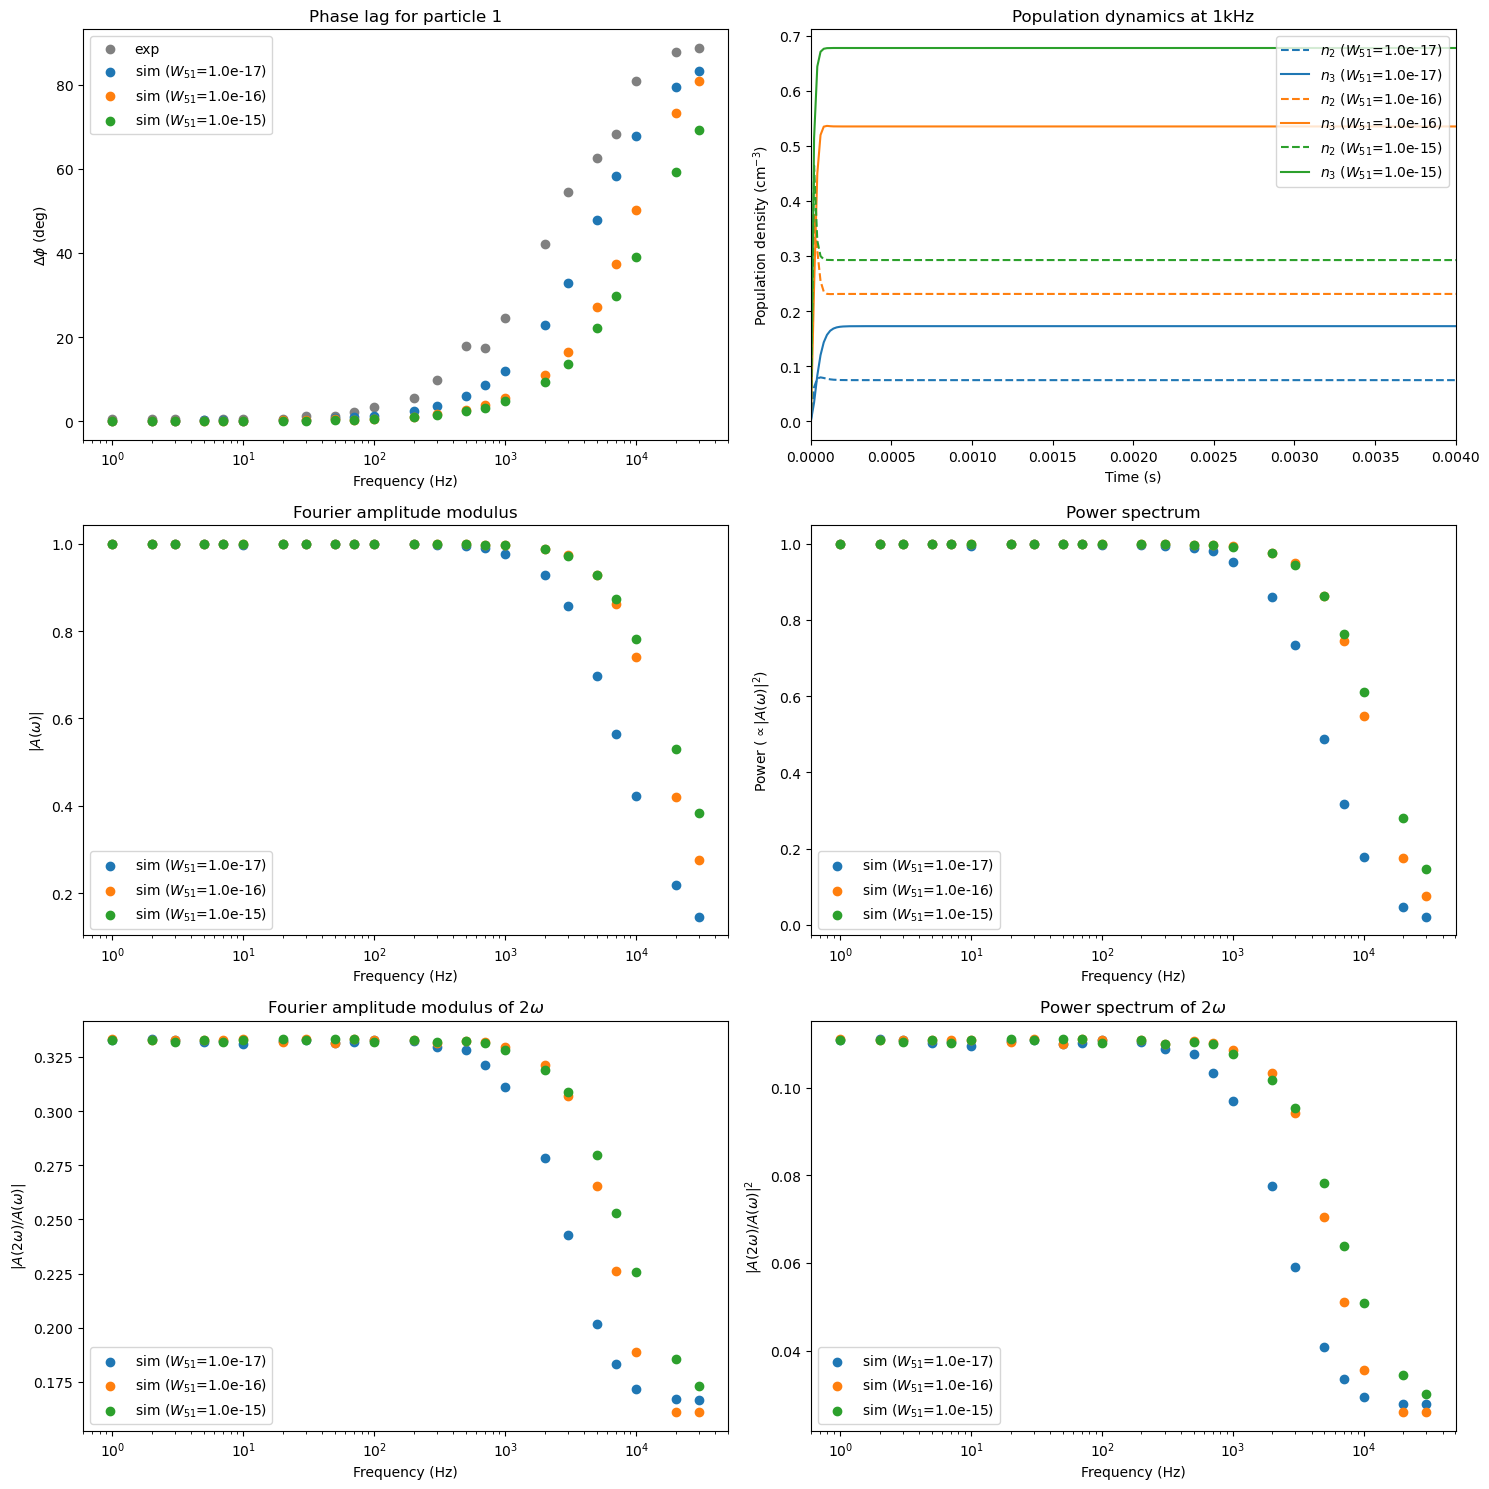

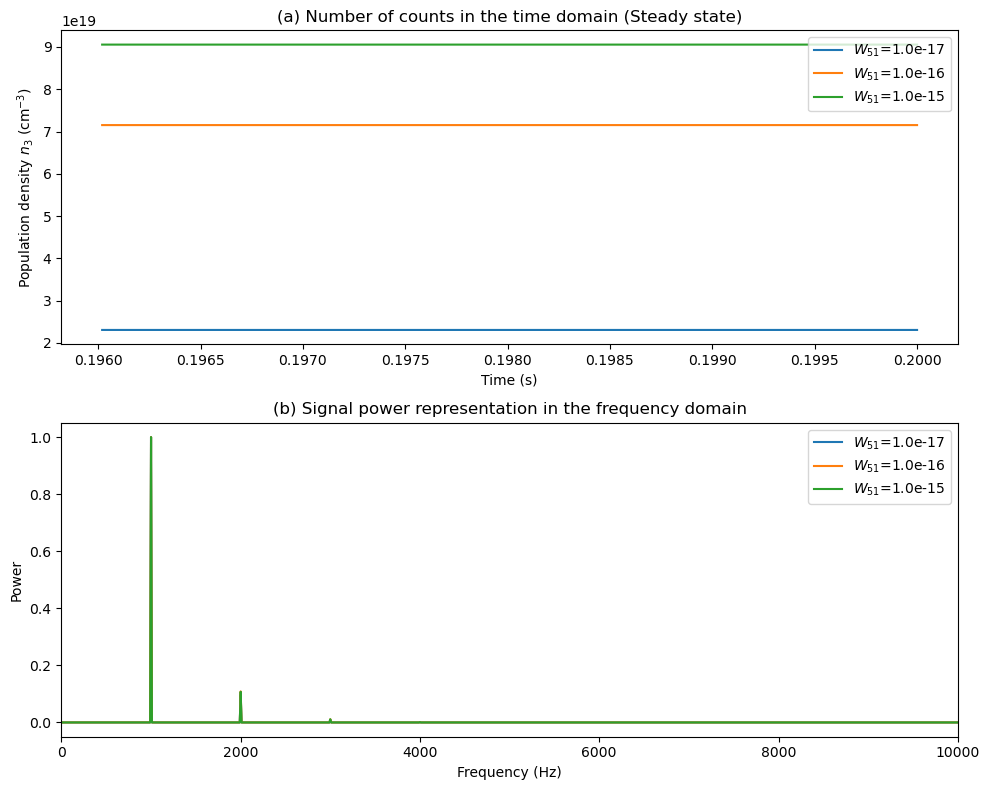

In [31]:
# Assumindo que funções como wp51, kp45, extrair_fase, get_fft_amp, adj_ph, 
# e variáveis como offset, amplitude, pd_list, n0, n1_0, n4_0 já estão definidas acima.

k21 = k21_initial
k31 = k31_initial
k54 = k54_initial
sigma = sigma_initial
ww51 = ww51_initial
ww52 = ww52_initial

params_w51 = [[ww51*10**(i-1), ww52, k21, k31, k54] for i in range(3)]

num_points = 23

fig, axs = plt.subplots(3, 2, figsize=(15, 15))

# ---> LISTA NOVA PARA ARMAZENAR OS DADOS DE 1kHz <---
dados_1kHz = []

for idx, param in enumerate(params_w51):
    # if iv_idx !=0: continue
    ww51, ww52, k21, k31, k54 = param
    print(f"k21 = {k21}")
    print(f"k31 = {k31}")
    print(f"k54 = {k54}")
    print(f"w51 = {ww51}")
    print(f"w52 = {ww52}")

    fases_calculadas = []

    for p_id, pd in enumerate(pd_list):
        if p_id != 0: continue
        frequencias_experimentais = pd[:num_points, 0] 
        fases_experimentais = pd[:num_points, 1] 
        W51, W52 = ww51, ww52
        sol_to_plot = []
        amps_list = []
        amps_list_2omega = []

        for f in frequencias_experimentais:
            # Simula 200 ciclos em tempo adimensional para garantir que o transiente morra
            t_span = (0, 200) 
            t_eval = np.linspace(t_span[0], t_span[1], 10000)
            sol = solve_ivp(
            odes, 
            t_span, 
            [n1_0/n0, 0, 0, n4_0/n0, 0], #x1 x2 x3 x4 x5 @ t=0
            t_eval=t_eval,
            args=(W51, W52, [k21, k31, k54], f), 
            method='Radau' # Mantendo o método Radau que demonstrou estabilidade acima
            )
            # Converte de volta para unidades físicas antes de extrair a fase
            n3 = (sol.y[2]) * n0 
            ts = (sol.t) * (1/f)
            n2 = (sol.y[1]) * n0 
            n11 = (sol.y[0]) * n0 

            if f == 1000:
                sol_to_plot = [ts, n11, n2, n3]
                # ---> SALVANDO SINAL PARA A NOVA FIGURA <---
                dados_1kHz.append((ts, n3, W51))

            fase_calc = extrair_fase(ts, n3, f)
            fases_calculadas.append(fase_calc)
            amps_list.append(get_fft_amp(ts, n3, f))
            amps_list_2omega.append(get_fft_amp(ts, n3, 2*f))

        fases_calculadas = np.unwrap(np.array(fases_calculadas))
        amps_list = np.array(amps_list)
        powers = amps_list**2

        amps_list_2omega = np.array(amps_list_2omega)

        amps_2omega_ad = [amps_list_2omega[i]/amps_list[i] for i in range(len(amps_list))]
        amps_2omega_ad = np.array(amps_2omega_ad)

        powers_2omega = amps_list_2omega**2
        powers_2omega_ad = amps_2omega_ad**2
        
        # Phase lag plot
        if idx == 0: 
            axs[0,0].scatter(frequencias_experimentais, adj_ph(fases_experimentais), color="gray", label="exp")
        axs[0,0].scatter(frequencias_experimentais, adj_ph(fases_calculadas), label=f"sim ($W_{{51}}$={W51:.1e})")
        axs[0,0].set_xscale("log")
        axs[0,0].set_ylabel("$\Delta \phi$ (deg)")
        axs[0,0].set_xlabel("Frequency (Hz)")
        axs[0,0].set_title("Phase lag for particle 1")

        # Population time evolution @ 1kHz
        ts, n11, n2, n3 = sol_to_plot
        linha, = axs[0,1].plot(ts, n2/n11.max(), linestyle="--",label=f"$n_2$ ($W_{{51}}$={W51:.1e})")
        axs[0,1].plot(ts, n3/n11.max(), color=linha.get_color(), label=f"$n_3$ ($W_{{51}}$={W51:.1e})")
        axs[0,1].set_ylabel("Population density (cm$^{-3}$)")
        axs[0,1].set_xlabel("Time (s)")
        axs[0,1].set_xlim([0,ts[int(len(ts)*(0.02))]])
        axs[0,1].set_title("Population dynamics at 1kHz")

        # Amplitudes plot
        axs[1,0].scatter(frequencias_experimentais, amps_list/amps_list.max(), label=f"sim ($W_{{51}}$={W51:.1e})")
        axs[1,0].set_ylabel("$|A(\omega)|$")
        axs[1,0].set_xlabel("Frequency (Hz)")
        axs[1,0].set_xscale("log")
        axs[1,0].set_title("Fourier amplitude modulus")

        # Power plot
        axs[1,1].scatter(frequencias_experimentais, powers/(powers).max(), label=f"sim ($W_{{51}}$={W51:.1e})")
        axs[1,1].set_ylabel("Power ($\propto |A(\omega)|^2$)")
        axs[1,1].set_xlabel("Frequency (Hz)")
        axs[1,1].set_xscale("log")
        axs[1,1].set_title("Power spectrum")

        # Amplitudes plot for 2omega
        axs[2,0].scatter(frequencias_experimentais, amps_2omega_ad, label=f"sim ($W_{{51}}$={W51:.1e})")
        axs[2,0].set_ylabel("$|A(2\omega)/A(\omega)|$")
        axs[2,0].set_xlabel("Frequency (Hz)")
        axs[2,0].set_xscale("log")
        axs[2,0].set_title("Fourier amplitude modulus of $2\omega$")

        # Power plot for 2omega
        axs[2,1].scatter(frequencias_experimentais, powers_2omega_ad, label=f"sim ($W_{{51}}$={W51:.1e})")
        axs[2,1].set_ylabel("$|A(2\omega)/A(\omega)|^2$")
        axs[2,1].set_xlabel("Frequency (Hz)")
        axs[2,1].set_xscale("log")
        axs[2,1].set_title("Power spectrum of $2\omega$")

axs[0,0].legend()
axs[0,1].legend()
axs[1,0].legend()
axs[1,1].legend()
axs[2,0].legend()
axs[2,1].legend()
fig.tight_layout()


# ---> CRIAÇÃO DA NOVA FIGURA PARA O ESPECTRO DE 1kHz <---
fig2, axs2 = plt.subplots(2, 1, figsize=(10, 8))

for ts_1k, n3_1k, w51_val in dados_1kHz:
    # 1. Domínio do tempo
    # Plotamos os últimos 4 ciclos (200 pontos no total, pois são 50 pts por ciclo)
    # Isso evita ver um bloco maciço de 200 ciclos e foca no regime estacionário
    axs2[0].plot(ts_1k[-200:], n3_1k[-200:], label=f"$W_{{51}}$={w51_val:.1e}")

    # 2. Domínio da frequência (Espectro de Potência)
    # Utilizamos a segunda metade do sinal para evitar vazamento espectral dos transientes
    meio = len(ts_1k) // 2
    ts_estacionario = ts_1k[meio:]
    n3_estacionario = n3_1k[meio:]
    
    N = len(ts_estacionario)
    dt = ts_estacionario[1] - ts_estacionario[0]
    
    yf = fft(n3_estacionario)
    xf = fftfreq(N, dt)
    
    # Filtro para pegar apenas frequências positivas (remove a componente DC em 0 Hz)
    idx_pos = xf > 0
    xf_pos = xf[idx_pos]
    power = np.abs(yf[idx_pos])**2
    
    axs2[1].plot(xf_pos, power/power.max(), label=f"$W_{{51}}$={w51_val:.1e}")

axs2[0].set_title("(a) Number of counts in the time domain (Steady state)")
axs2[0].set_xlabel("Time (s)")
axs2[0].set_ylabel("Population density $n_3$ (cm$^{-3}$)")
axs2[0].legend(loc="upper right")

axs2[1].set_title("(b) Signal power representation in the frequency domain")
axs2[1].set_xlabel("Frequency (Hz)")
axs2[1].set_ylabel("Power")
axs2[1].set_xlim([0, 10000]) # Foca nos harmônicos até 10kHz conforme sua imagem de referência
axs2[1].legend(loc="upper right")
fig2.tight_layout()

# O plt.show() agora vai renderizar ambas as janelas (fig e fig2)
plt.show()

#### Varying $W_{52}$

k21 = 598.0
k31 = 23066.7
k54 = 1348.8
w51 = 1e-16
w52 = 1e-17
k21 = 598.0
k31 = 23066.7
k54 = 1348.8
w51 = 1e-16
w52 = 1e-16
k21 = 598.0
k31 = 23066.7
k54 = 1348.8
w51 = 1e-16
w52 = 1e-15


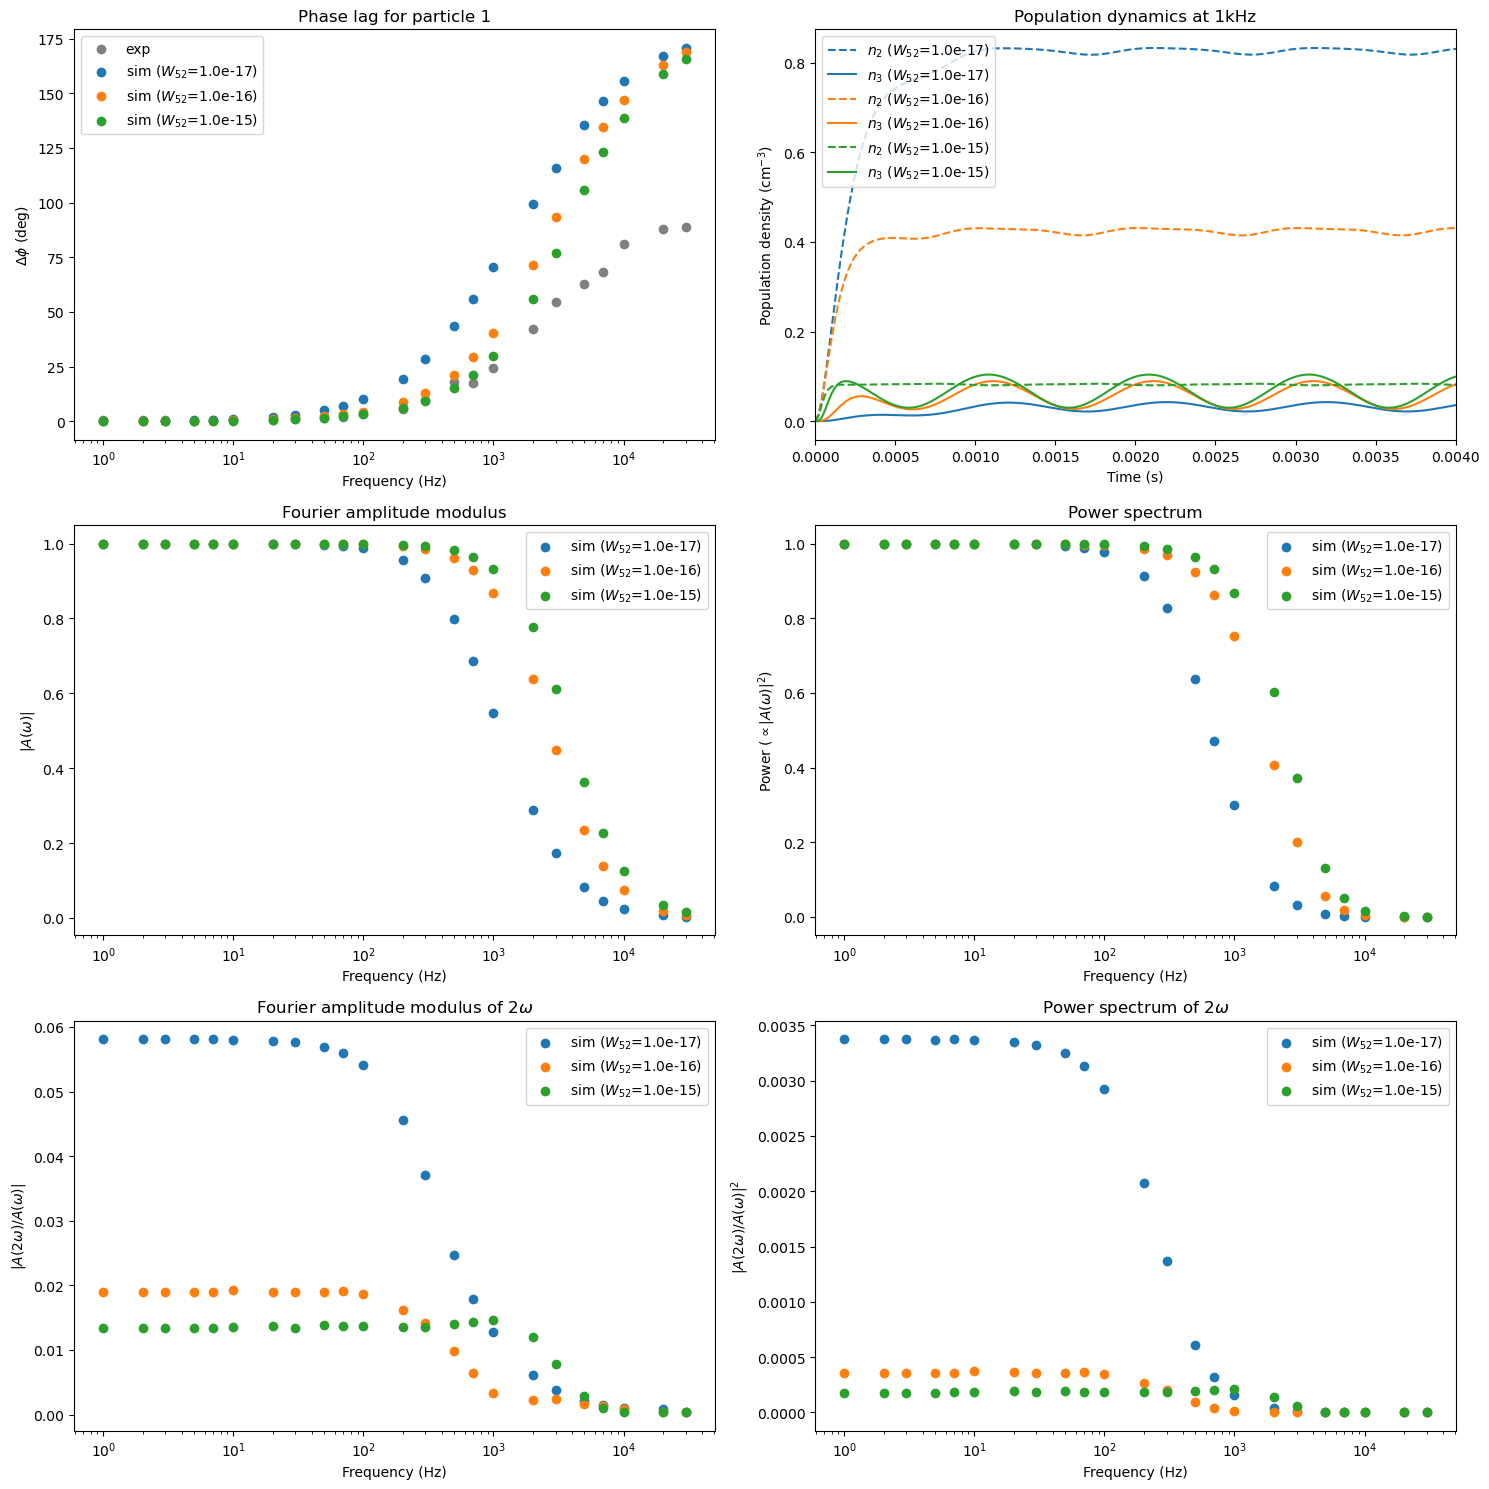

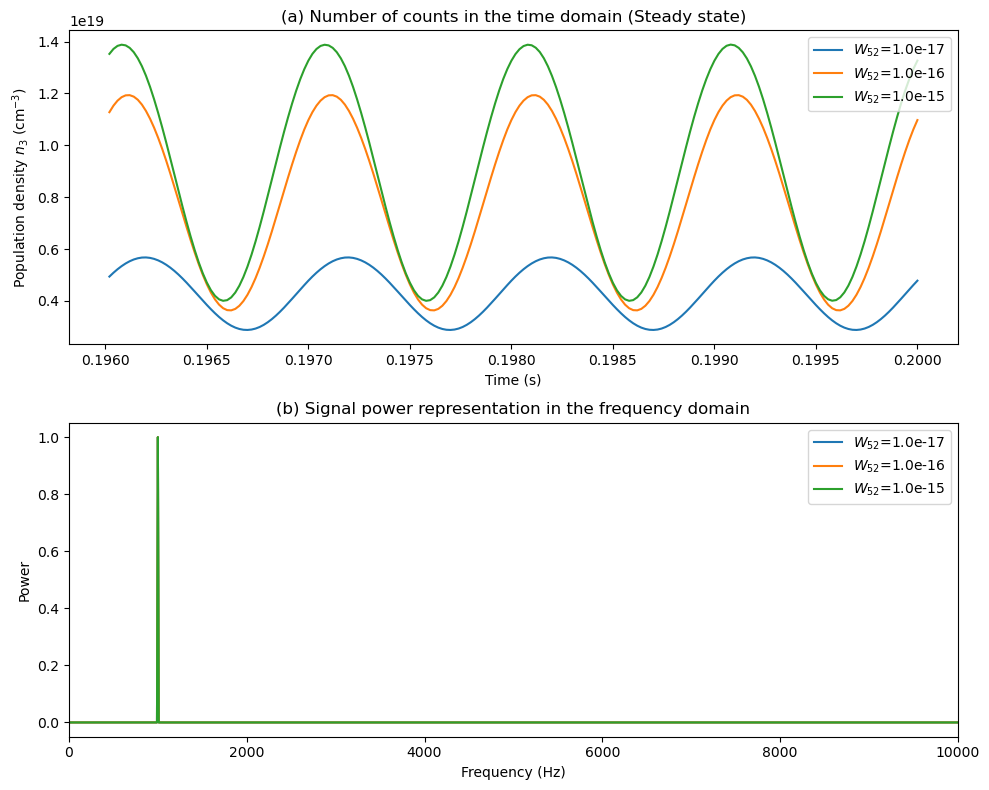

In [9]:
k21 = k21_initial
k31 = k31_initial
k54 = k54_initial
sigma = sigma_initial
ww51 = ww51_initial
ww52 = ww52_initial

params_w52 = [[ww51, ww52*10**(i-1), k21, k31, k54] for i in range(3)]

num_points = 23

fig, axs = plt.subplots(3, 2, figsize=(15, 15))

# ---> LISTA NOVA PARA ARMAZENAR OS DADOS DE 1kHz <---
dados_1kHz = []

for idx, param in enumerate(params_w52):
    # if iv_idx !=0: continue
    ww51, ww52, k21, k31, k54 = param
    print(f"k21 = {k21}")
    print(f"k31 = {k31}")
    print(f"k54 = {k54}")
    print(f"w51 = {ww51}")
    print(f"w52 = {ww52}")

    fases_calculadas = []

    for p_id, pd in enumerate(pd_list):
        if p_id != 0: continue
        frequencias_experimentais = pd[:num_points, 0] 
        fases_experimentais = pd[:num_points, 1] 
        W51, W52 = ww51, ww52
        sol_to_plot = []
        amps_list = []
        amps_list_2omega = []

        for f in frequencias_experimentais:
            # Simula 200 ciclos em tempo adimensional para garantir que o transiente morra
            t_span = (0, 200) 
            t_eval = np.linspace(t_span[0], t_span[1], 10000)
            sol = solve_ivp(
            odes, 
            t_span, 
            [n1_0/n0, 0, 0, n4_0/n0, 0], #x1 x2 x3 x4 x5 @ t=0
            t_eval=t_eval,
            args=(W51, W52, [k21, k31, k54], f), 
            method='Radau' # Mantendo o método Radau que demonstrou estabilidade acima
            )
            # Converte de volta para unidades físicas antes de extrair a fase
            n3 = (sol.y[2]) * n0 
            ts = (sol.t) * (1/f)
            n2 = (sol.y[1]) * n0 
            n11 = (sol.y[0]) * n0 

            if f == 1000:
                sol_to_plot = [ts, n11, n2, n3]
                # ---> SALVANDO SINAL PARA A NOVA FIGURA <---
                dados_1kHz.append((ts, n3, W52))

            fase_calc = extrair_fase(ts, n3, f)
            fases_calculadas.append(fase_calc)
            amps_list.append(get_fft_amp(ts, n3, f))
            amps_list_2omega.append(get_fft_amp(ts, n3, 2*f))

        fases_calculadas = np.unwrap(np.array(fases_calculadas))
        amps_list = np.array(amps_list)
        powers = amps_list**2

        amps_list_2omega = np.array(amps_list_2omega)

        amps_2omega_ad = [amps_list_2omega[i]/amps_list[i] for i in range(len(amps_list))]
        amps_2omega_ad = np.array(amps_2omega_ad)

        powers_2omega = amps_list_2omega**2
        powers_2omega_ad = amps_2omega_ad**2
        
        # Phase lag plot
        if idx == 0: 
            axs[0,0].scatter(frequencias_experimentais, adj_ph(fases_experimentais), color="gray", label="exp")
        axs[0,0].scatter(frequencias_experimentais, adj_ph(fases_calculadas), label=f"sim ($W_{{52}}$={W52:.1e})")
        axs[0,0].set_xscale("log")
        axs[0,0].set_ylabel("$\Delta \phi$ (deg)")
        axs[0,0].set_xlabel("Frequency (Hz)")
        axs[0,0].set_title("Phase lag for particle 1")

        # Population time evolution @ 1kHz
        ts, n11, n2, n3 = sol_to_plot
        linha, = axs[0,1].plot(ts, n2/n11.max(), linestyle="--",label=f"$n_2$ ($W_{{52}}$={W52:.1e})")
        axs[0,1].plot(ts, n3/n11.max(), color=linha.get_color(), label=f"$n_3$ ($W_{{52}}$={W52:.1e})")
        axs[0,1].set_ylabel("Population density (cm$^{-3}$)")
        axs[0,1].set_xlabel("Time (s)")
        axs[0,1].set_xlim([0,ts[int(len(ts)*(0.02))]])
        axs[0,1].set_title("Population dynamics at 1kHz")

        # Amplitudes plot
        axs[1,0].scatter(frequencias_experimentais, amps_list/amps_list.max(), label=f"sim ($W_{{52}}$={W52:.1e})")
        axs[1,0].set_ylabel("$|A(\omega)|$")
        axs[1,0].set_xlabel("Frequency (Hz)")
        axs[1,0].set_xscale("log")
        axs[1,0].set_title("Fourier amplitude modulus")

        # Power plot
        axs[1,1].scatter(frequencias_experimentais, powers/(powers).max(), label=f"sim ($W_{{52}}$={W52:.1e})")
        axs[1,1].set_ylabel("Power ($\propto |A(\omega)|^2$)")
        axs[1,1].set_xlabel("Frequency (Hz)")
        axs[1,1].set_xscale("log")
        axs[1,1].set_title("Power spectrum")

        # Amplitudes plot for 2omega
        axs[2,0].scatter(frequencias_experimentais, amps_2omega_ad, label=f"sim ($W_{{52}}$={W52:.1e})")
        axs[2,0].set_ylabel("$|A(2\omega)/A(\omega)|$")
        axs[2,0].set_xlabel("Frequency (Hz)")
        axs[2,0].set_xscale("log")
        axs[2,0].set_title("Fourier amplitude modulus of $2\omega$")

        # Power plot for 2omega
        axs[2,1].scatter(frequencias_experimentais, powers_2omega_ad, label=f"sim ($W_{{52}}$={W52:.1e})")
        axs[2,1].set_ylabel("$|A(2\omega)/A(\omega)|^2$")
        axs[2,1].set_xlabel("Frequency (Hz)")
        axs[2,1].set_xscale("log")
        axs[2,1].set_title("Power spectrum of $2\omega$")

axs[0,0].legend()
axs[0,1].legend()
axs[1,0].legend()
axs[1,1].legend()
axs[2,0].legend()
axs[2,1].legend()
fig.tight_layout()


# ---> CRIAÇÃO DA NOVA FIGURA PARA O ESPECTRO DE 1kHz <---
fig2, axs2 = plt.subplots(2, 1, figsize=(10, 8))

for ts_1k, n3_1k, w52_val in dados_1kHz:
    # 1. Domínio do tempo
    # Plotamos os últimos 4 ciclos (200 pontos no total, pois são 50 pts por ciclo)
    # Isso evita ver um bloco maciço de 200 ciclos e foca no regime estacionário
    axs2[0].plot(ts_1k[-200:], n3_1k[-200:], label=f"$W_{{52}}$={w52_val:.1e}")

    # 2. Domínio da frequência (Espectro de Potência)
    # Utilizamos a segunda metade do sinal para evitar vazamento espectral dos transientes
    meio = len(ts_1k) // 2
    ts_estacionario = ts_1k[meio:]
    n3_estacionario = n3_1k[meio:]
    
    N = len(ts_estacionario)
    dt = ts_estacionario[1] - ts_estacionario[0]
    
    yf = fft(n3_estacionario)
    xf = fftfreq(N, dt)
    
    # Filtro para pegar apenas frequências positivas (remove a componente DC em 0 Hz)
    idx_pos = xf > 0
    xf_pos = xf[idx_pos]
    power = np.abs(yf[idx_pos])**2
    
    axs2[1].plot(xf_pos, power/power.max(), label=f"$W_{{52}}$={w52_val:.1e}")

axs2[0].set_title("(a) Number of counts in the time domain (Steady state)")
axs2[0].set_xlabel("Time (s)")
axs2[0].set_ylabel("Population density $n_3$ (cm$^{-3}$)")
axs2[0].legend(loc="upper right")

axs2[1].set_title("(b) Signal power representation in the frequency domain")
axs2[1].set_xlabel("Frequency (Hz)")
axs2[1].set_ylabel("Power")
axs2[1].set_xlim([0, 10000]) # Foca nos harmônicos até 10kHz conforme sua imagem de referência
axs2[1].legend(loc="upper right")
fig2.tight_layout()

# O plt.show() agora vai renderizar ambas as janelas (fig e fig2)
plt.show()

#### Varying $k_{21}$

k21 = 59.800000000000004
k31 = 23066.7
k54 = 1348.8
w51 = 1e-16
w52 = 1e-16
k21 = 598.0
k31 = 23066.7
k54 = 1348.8
w51 = 1e-16
w52 = 1e-16
k21 = 5980.0
k31 = 23066.7
k54 = 1348.8
w51 = 1e-16
w52 = 1e-16


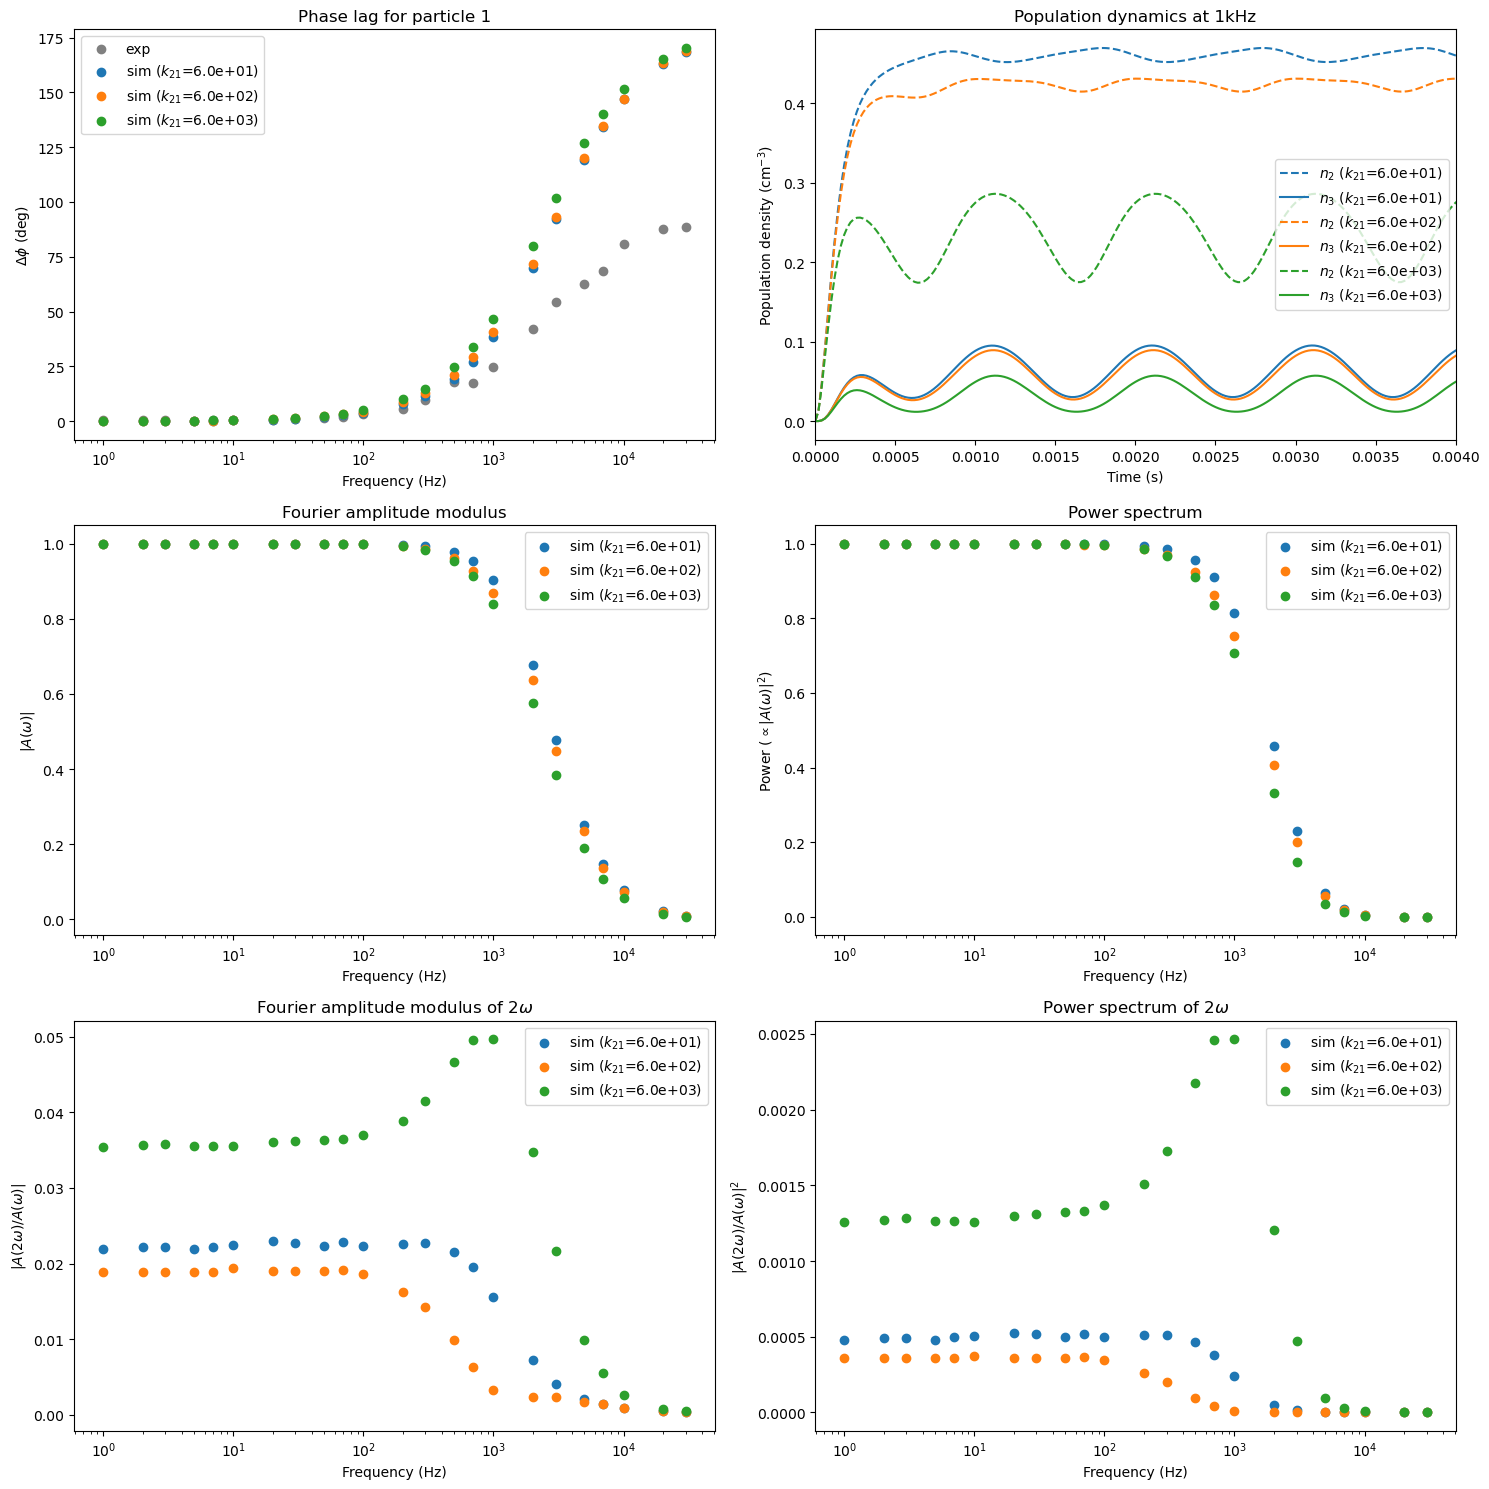

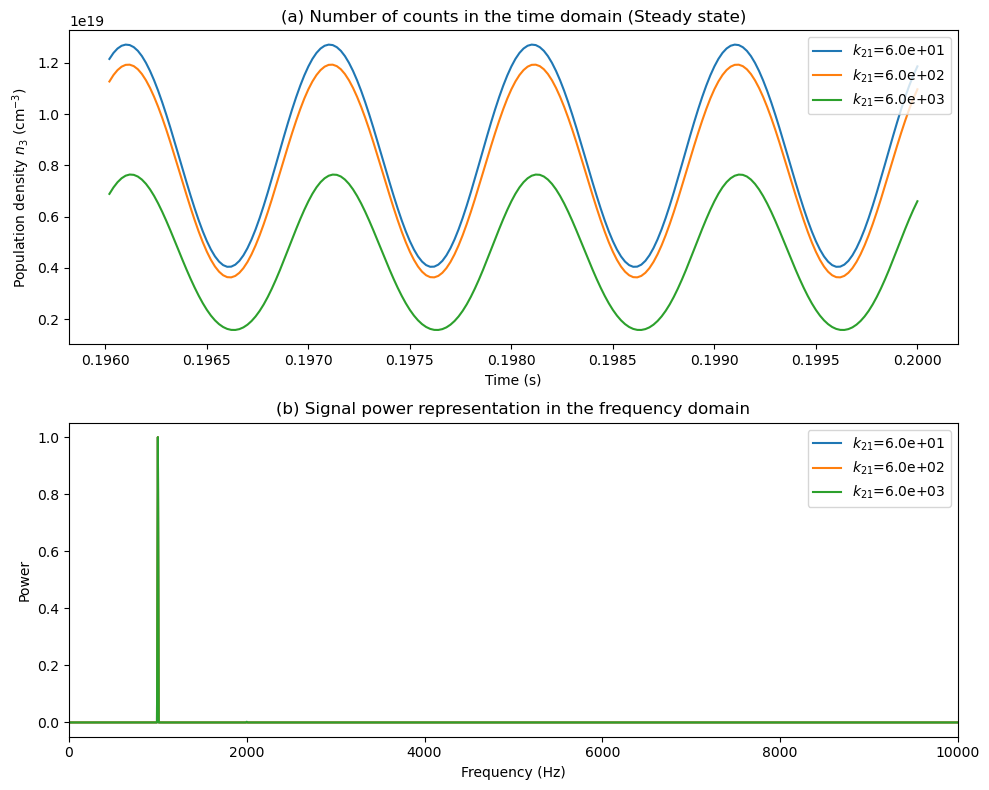

In [10]:
k21 = k21_initial
k31 = k31_initial
k54 = k54_initial
sigma = sigma_initial
ww51 = ww51_initial
ww52 = ww52_initial

params_k21 = [[ww51, ww52, k21*10**(i-1), k31, k54] for i in range(3)] #Varia de 0.5, 1.0, 1.5

num_points = 23

fig, axs = plt.subplots(3, 2, figsize=(15, 15))

# ---> LISTA NOVA PARA ARMAZENAR OS DADOS DE 1kHz <---
dados_1kHz = []

for idx, param in enumerate(params_k21):
    # if iv_idx !=0: continue
    ww51, ww52, k21, k31, k54 = param
    print(f"k21 = {k21}")
    print(f"k31 = {k31}")
    print(f"k54 = {k54}")
    print(f"w51 = {ww51}")
    print(f"w52 = {ww52}")

    fases_calculadas = []

    for p_id, pd in enumerate(pd_list):
        if p_id != 0: continue
        frequencias_experimentais = pd[:num_points, 0] 
        fases_experimentais = pd[:num_points, 1] 
        W51, W52 = ww51, ww52
        sol_to_plot = []
        amps_list = []
        amps_list_2omega = []

        for f in frequencias_experimentais:
            # Simula 200 ciclos em tempo adimensional para garantir que o transiente morra
            t_span = (0, 200) 
            t_eval = np.linspace(t_span[0], t_span[1], 10000)
            sol = solve_ivp(
            odes, 
            t_span, 
            [n1_0/n0, 0, 0, n4_0/n0, 0], #x1 x2 x3 x4 x5 @ t=0
            t_eval=t_eval,
            args=(W51, W52, [k21, k31, k54], f), 
            method='Radau' # Mantendo o método Radau que demonstrou estabilidade acima
            )
            # Converte de volta para unidades físicas antes de extrair a fase
            n3 = (sol.y[2]) * n0 
            ts = (sol.t) * (1/f)
            n2 = (sol.y[1]) * n0 
            n11 = (sol.y[0]) * n0 

            if f == 1000:
                sol_to_plot = [ts, n11, n2, n3]
                # ---> SALVANDO SINAL PARA A NOVA FIGURA <---
                dados_1kHz.append((ts, n3, k21))

            fase_calc = extrair_fase(ts, n3, f)
            fases_calculadas.append(fase_calc)
            amps_list.append(get_fft_amp(ts, n3, f))
            amps_list_2omega.append(get_fft_amp(ts, n3, 2*f))

        fases_calculadas = np.unwrap(np.array(fases_calculadas))
        amps_list = np.array(amps_list)
        powers = amps_list**2

        amps_list_2omega = np.array(amps_list_2omega)

        amps_2omega_ad = [amps_list_2omega[i]/amps_list[i] for i in range(len(amps_list))]
        amps_2omega_ad = np.array(amps_2omega_ad)

        powers_2omega = amps_list_2omega**2
        powers_2omega_ad = amps_2omega_ad**2
        
        # Phase lag plot
        if idx == 0: 
            axs[0,0].scatter(frequencias_experimentais, adj_ph(fases_experimentais), color="gray", label="exp")
        axs[0,0].scatter(frequencias_experimentais, adj_ph(fases_calculadas), label=f"sim ($k_{{21}}$={k21:.1e})")
        axs[0,0].set_xscale("log")
        axs[0,0].set_ylabel("$\Delta \phi$ (deg)")
        axs[0,0].set_xlabel("Frequency (Hz)")
        axs[0,0].set_title("Phase lag for particle 1")

        # Population time evolution @ 1kHz
        ts, n11, n2, n3 = sol_to_plot
        linha, = axs[0,1].plot(ts, n2/n11.max(), linestyle="--",label=f"$n_2$ ($k_{{21}}$={k21:.1e})")
        axs[0,1].plot(ts, n3/n11.max(), color=linha.get_color(), label=f"$n_3$ ($k_{{21}}$={k21:.1e})")
        axs[0,1].set_ylabel("Population density (cm$^{-3}$)")
        axs[0,1].set_xlabel("Time (s)")
        axs[0,1].set_xlim([0,ts[int(len(ts)*(0.02))]])
        axs[0,1].set_title("Population dynamics at 1kHz")

        # Amplitudes plot
        axs[1,0].scatter(frequencias_experimentais, amps_list/amps_list.max(), label=f"sim ($k_{{21}}$={k21:.1e})")
        axs[1,0].set_ylabel("$|A(\omega)|$")
        axs[1,0].set_xlabel("Frequency (Hz)")
        axs[1,0].set_xscale("log")
        axs[1,0].set_title("Fourier amplitude modulus")

        # Power plot
        axs[1,1].scatter(frequencias_experimentais, powers/(powers).max(), label=f"sim ($k_{{21}}$={k21:.1e})")
        axs[1,1].set_ylabel("Power ($\propto |A(\omega)|^2$)")
        axs[1,1].set_xlabel("Frequency (Hz)")
        axs[1,1].set_xscale("log")
        axs[1,1].set_title("Power spectrum")

        # Amplitudes plot for 2omega
        axs[2,0].scatter(frequencias_experimentais, amps_2omega_ad, label=f"sim ($k_{{21}}$={k21:.1e})")
        axs[2,0].set_ylabel("$|A(2\omega)/A(\omega)|$")
        axs[2,0].set_xlabel("Frequency (Hz)")
        axs[2,0].set_xscale("log")
        axs[2,0].set_title("Fourier amplitude modulus of $2\omega$")

        # Power plot for 2omega
        axs[2,1].scatter(frequencias_experimentais, powers_2omega_ad, label=f"sim ($k_{{21}}$={k21:.1e})")
        axs[2,1].set_ylabel("$|A(2\omega)/A(\omega)|^2$")
        axs[2,1].set_xlabel("Frequency (Hz)")
        axs[2,1].set_xscale("log")
        axs[2,1].set_title("Power spectrum of $2\omega$")

axs[0,0].legend()
axs[0,1].legend()
axs[1,0].legend()
axs[1,1].legend()
axs[2,0].legend()
axs[2,1].legend()
fig.tight_layout()


# ---> CRIAÇÃO DA NOVA FIGURA PARA O ESPECTRO DE 1kHz <---
fig2, axs2 = plt.subplots(2, 1, figsize=(10, 8))

for ts_1k, n3_1k, k21_val in dados_1kHz:
    # 1. Domínio do tempo
    # Plotamos os últimos 4 ciclos (200 pontos no total, pois são 50 pts por ciclo)
    # Isso evita ver um bloco maciço de 200 ciclos e foca no regime estacionário
    axs2[0].plot(ts_1k[-200:], n3_1k[-200:], label=f"$k_{{21}}$={k21_val:.1e}")

    # 2. Domínio da frequência (Espectro de Potência)
    # Utilizamos a segunda metade do sinal para evitar vazamento espectral dos transientes
    meio = len(ts_1k) // 2
    ts_estacionario = ts_1k[meio:]
    n3_estacionario = n3_1k[meio:]
    
    N = len(ts_estacionario)
    dt = ts_estacionario[1] - ts_estacionario[0]
    
    yf = fft(n3_estacionario)
    xf = fftfreq(N, dt)
    
    # Filtro para pegar apenas frequências positivas (remove a componente DC em 0 Hz)
    idx_pos = xf > 0
    xf_pos = xf[idx_pos]
    power = np.abs(yf[idx_pos])**2
    
    axs2[1].plot(xf_pos, power/power.max(), label=f"$k_{{21}}$={k21_val:.1e}")

axs2[0].set_title("(a) Number of counts in the time domain (Steady state)")
axs2[0].set_xlabel("Time (s)")
axs2[0].set_ylabel("Population density $n_3$ (cm$^{-3}$)")
axs2[0].legend(loc="upper right")

axs2[1].set_title("(b) Signal power representation in the frequency domain")
axs2[1].set_xlabel("Frequency (Hz)")
axs2[1].set_ylabel("Power")
axs2[1].set_xlim([0, 10000]) # Foca nos harmônicos até 10kHz conforme sua imagem de referência
axs2[1].legend(loc="upper right")
fig2.tight_layout()

# O plt.show() agora vai renderizar ambas as janelas (fig e fig2)
plt.show()

#### Varying $k_{31}$

k21 = 598.0
k31 = 2306.67
k54 = 1348.8
w51 = 1e-16
w52 = 1e-16
k21 = 598.0
k31 = 23066.7
k54 = 1348.8
w51 = 1e-16
w52 = 1e-16
k21 = 598.0
k31 = 230667.0
k54 = 1348.8
w51 = 1e-16
w52 = 1e-16


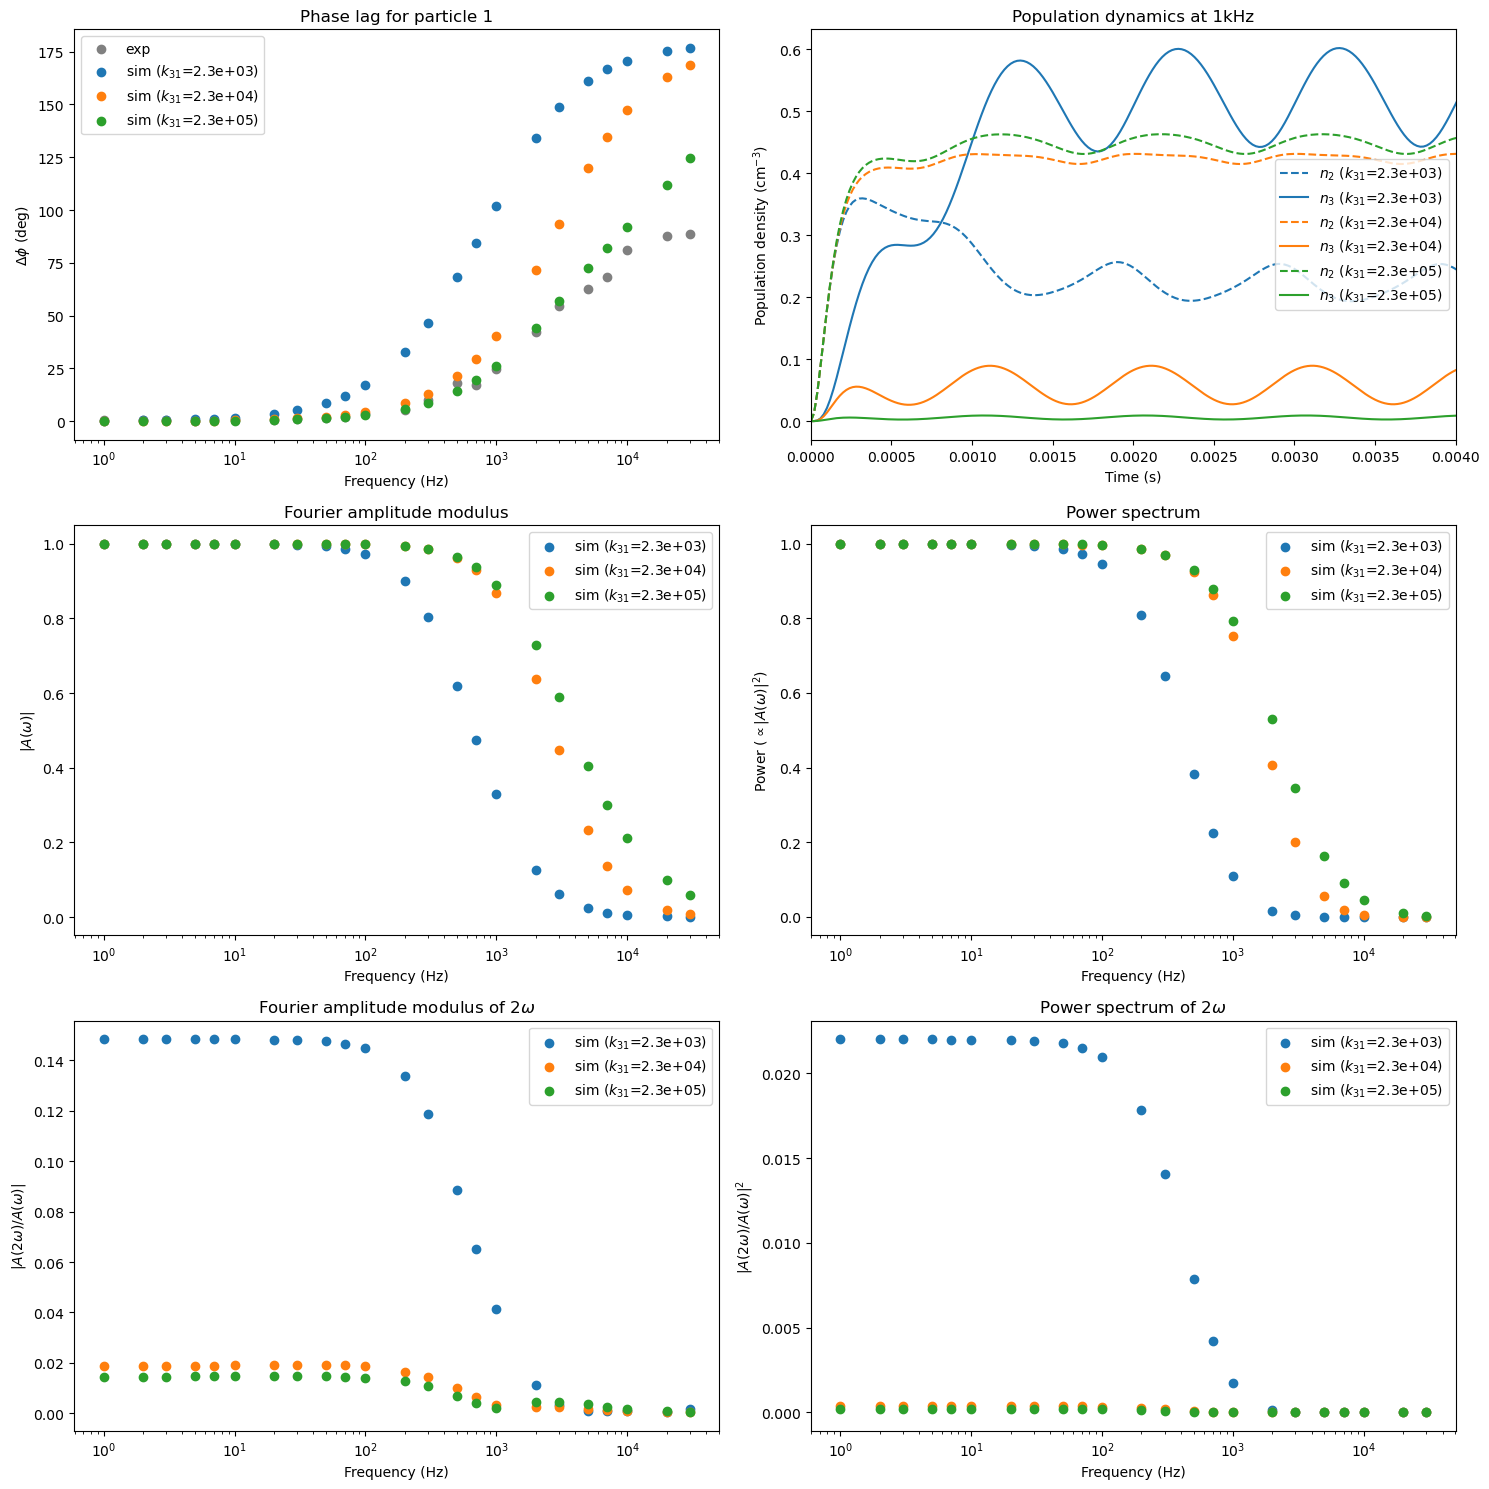

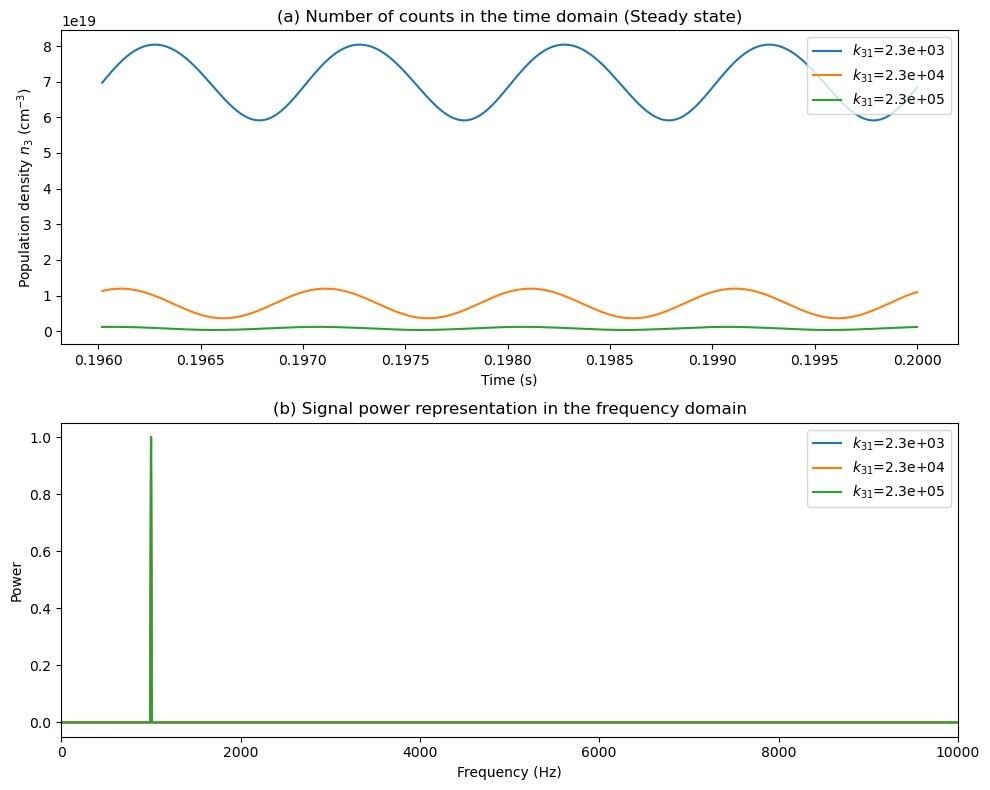

In [11]:
k21 = k21_initial
k31 = k31_initial
k54 = k54_initial
sigma = sigma_initial
ww51 = ww51_initial
ww52 = ww52_initial

params_k31 = [[ww51, ww52, k21, k31*10**(i-1), k54] for i in range(3)] #Varia de 0.5, 1.0, 1.5


num_points = 23

fig, axs = plt.subplots(3, 2, figsize=(15, 15))

# ---> LISTA NOVA PARA ARMAZENAR OS DADOS DE 1kHz <---
dados_1kHz = []

for idx, param in enumerate(params_k31):
    # if iv_idx !=0: continue
    ww51, ww52, k21, k31, k54 = param
    print(f"k21 = {k21}")
    print(f"k31 = {k31}")
    print(f"k54 = {k54}")
    print(f"w51 = {ww51}")
    print(f"w52 = {ww52}")

    fases_calculadas = []

    for p_id, pd in enumerate(pd_list):
        if p_id != 0: continue
        frequencias_experimentais = pd[:num_points, 0] 
        fases_experimentais = pd[:num_points, 1] 
        W51, W52 = ww51, ww52
        sol_to_plot = []
        amps_list = []
        amps_list_2omega = []

        for f in frequencias_experimentais:
            # Simula 200 ciclos em tempo adimensional para garantir que o transiente morra
            t_span = (0, 200) 
            t_eval = np.linspace(t_span[0], t_span[1], 10000)
            sol = solve_ivp(
            odes, 
            t_span, 
            [n1_0/n0, 0, 0, n4_0/n0, 0], #x1 x2 x3 x4 x5 @ t=0
            t_eval=t_eval,
            args=(W51, W52, [k21, k31, k54], f), 
            method='Radau' # Mantendo o método Radau que demonstrou estabilidade acima
            )
            # Converte de volta para unidades físicas antes de extrair a fase
            n3 = (sol.y[2]) * n0 
            ts = (sol.t) * (1/f)
            n2 = (sol.y[1]) * n0 
            n11 = (sol.y[0]) * n0 

            if f == 1000:
                sol_to_plot = [ts, n11, n2, n3]
                # ---> SALVANDO SINAL PARA A NOVA FIGURA <---
                dados_1kHz.append((ts, n3, k31)) 

            fase_calc = extrair_fase(ts, n3, f)
            fases_calculadas.append(fase_calc)
            amps_list.append(get_fft_amp(ts, n3, f))
            amps_list_2omega.append(get_fft_amp(ts, n3, 2*f))

        fases_calculadas = np.unwrap(np.array(fases_calculadas))
        amps_list = np.array(amps_list)
        powers = amps_list**2

        amps_list_2omega = np.array(amps_list_2omega)

        amps_2omega_ad = [amps_list_2omega[i]/amps_list[i] for i in range(len(amps_list))]
        amps_2omega_ad = np.array(amps_2omega_ad)

        powers_2omega = amps_list_2omega**2
        powers_2omega_ad = amps_2omega_ad**2
        
        # Phase lag plot
        if idx == 0: 
            axs[0,0].scatter(frequencias_experimentais, adj_ph(fases_experimentais), color="gray", label="exp")
        axs[0,0].scatter(frequencias_experimentais, adj_ph(fases_calculadas), label=f"sim ($k_{{31}}$={k31:.1e})")
        axs[0,0].set_xscale("log")
        axs[0,0].set_ylabel("$\Delta \phi$ (deg)")
        axs[0,0].set_xlabel("Frequency (Hz)")
        axs[0,0].set_title("Phase lag for particle 1")

        # Population time evolution @ 1kHz
        ts, n11, n2, n3 = sol_to_plot
        linha, = axs[0,1].plot(ts, n2/n11.max(), linestyle="--",label=f"$n_2$ ($k_{{31}}$={k31:.1e})")
        axs[0,1].plot(ts, n3/n11.max(), color=linha.get_color(), label=f"$n_3$ ($k_{{31}}$={k31:.1e})")
        axs[0,1].set_ylabel("Population density (cm$^{-3}$)")
        axs[0,1].set_xlabel("Time (s)")
        axs[0,1].set_xlim([0,ts[int(len(ts)*(0.02))]])
        axs[0,1].set_title("Population dynamics at 1kHz")

        # Amplitudes plot
        axs[1,0].scatter(frequencias_experimentais, amps_list/amps_list.max(), label=f"sim ($k_{{31}}$={k31:.1e})")
        axs[1,0].set_ylabel("$|A(\omega)|$")
        axs[1,0].set_xlabel("Frequency (Hz)")
        axs[1,0].set_xscale("log")
        axs[1,0].set_title("Fourier amplitude modulus")

        # Power plot
        axs[1,1].scatter(frequencias_experimentais, powers/(powers).max(), label=f"sim ($k_{{31}}$={k31:.1e})")
        axs[1,1].set_ylabel("Power ($\propto |A(\omega)|^2$)")
        axs[1,1].set_xlabel("Frequency (Hz)")
        axs[1,1].set_xscale("log")
        axs[1,1].set_title("Power spectrum")

        # Amplitudes plot for 2omega
        axs[2,0].scatter(frequencias_experimentais, amps_2omega_ad, label=f"sim ($k_{{31}}$={k31:.1e})")
        axs[2,0].set_ylabel("$|A(2\omega)/A(\omega)|$")
        axs[2,0].set_xlabel("Frequency (Hz)")
        axs[2,0].set_xscale("log")
        axs[2,0].set_title("Fourier amplitude modulus of $2\omega$")

        # Power plot for 2omega
        axs[2,1].scatter(frequencias_experimentais, powers_2omega_ad, label=f"sim ($k_{{31}}$={k31:.1e})")
        axs[2,1].set_ylabel("$|A(2\omega)/A(\omega)|^2$")
        axs[2,1].set_xlabel("Frequency (Hz)")
        axs[2,1].set_xscale("log")
        axs[2,1].set_title("Power spectrum of $2\omega$")

axs[0,0].legend()
axs[0,1].legend()
axs[1,0].legend()
axs[1,1].legend()
axs[2,0].legend()
axs[2,1].legend()
fig.tight_layout()


# ---> CRIAÇÃO DA NOVA FIGURA PARA O ESPECTRO DE 1kHz <---
fig2, axs2 = plt.subplots(2, 1, figsize=(10, 8))

for ts_1k, n3_1k, k31_val in dados_1kHz:
    # 1. Domínio do tempo
    # Plotamos os últimos 4 ciclos (200 pontos no total, pois são 50 pts por ciclo)
    # Isso evita ver um bloco maciço de 200 ciclos e foca no regime estacionário
    axs2[0].plot(ts_1k[-200:], n3_1k[-200:], label=f"$k_{{31}}$={k31_val:.1e}")

    # 2. Domínio da frequência (Espectro de Potência)
    # Utilizamos a segunda metade do sinal para evitar vazamento espectral dos transientes
    meio = len(ts_1k) // 2
    ts_estacionario = ts_1k[meio:]
    n3_estacionario = n3_1k[meio:]
    
    N = len(ts_estacionario)
    dt = ts_estacionario[1] - ts_estacionario[0]
    
    yf = fft(n3_estacionario)
    xf = fftfreq(N, dt)
    
    # Filtro para pegar apenas frequências positivas (remove a componente DC em 0 Hz)
    idx_pos = xf > 0
    xf_pos = xf[idx_pos]
    power = np.abs(yf[idx_pos])**2
    
    axs2[1].plot(xf_pos, power/power.max(), label=f"$k_{{31}}$={k31_val:.1e}")

axs2[0].set_title("(a) Number of counts in the time domain (Steady state)")
axs2[0].set_xlabel("Time (s)")
axs2[0].set_ylabel("Population density $n_3$ (cm$^{-3}$)")
axs2[0].legend(loc="upper right")

axs2[1].set_title("(b) Signal power representation in the frequency domain")
axs2[1].set_xlabel("Frequency (Hz)")
axs2[1].set_ylabel("Power")
axs2[1].set_xlim([0, 10000]) # Foca nos harmônicos até 10kHz conforme sua imagem de referência
axs2[1].legend(loc="upper right")
fig2.tight_layout()

# O plt.show() agora vai renderizar ambas as janelas (fig e fig2)
plt.show()

#### Varying $k_{54}$

k21 = 598.0
k31 = 23066.7
k54 = 134.88
w51 = 1e-16
w52 = 1e-16
k21 = 598.0
k31 = 23066.7
k54 = 1348.8
w51 = 1e-16
w52 = 1e-16
k21 = 598.0
k31 = 23066.7
k54 = 13488.0
w51 = 1e-16
w52 = 1e-16


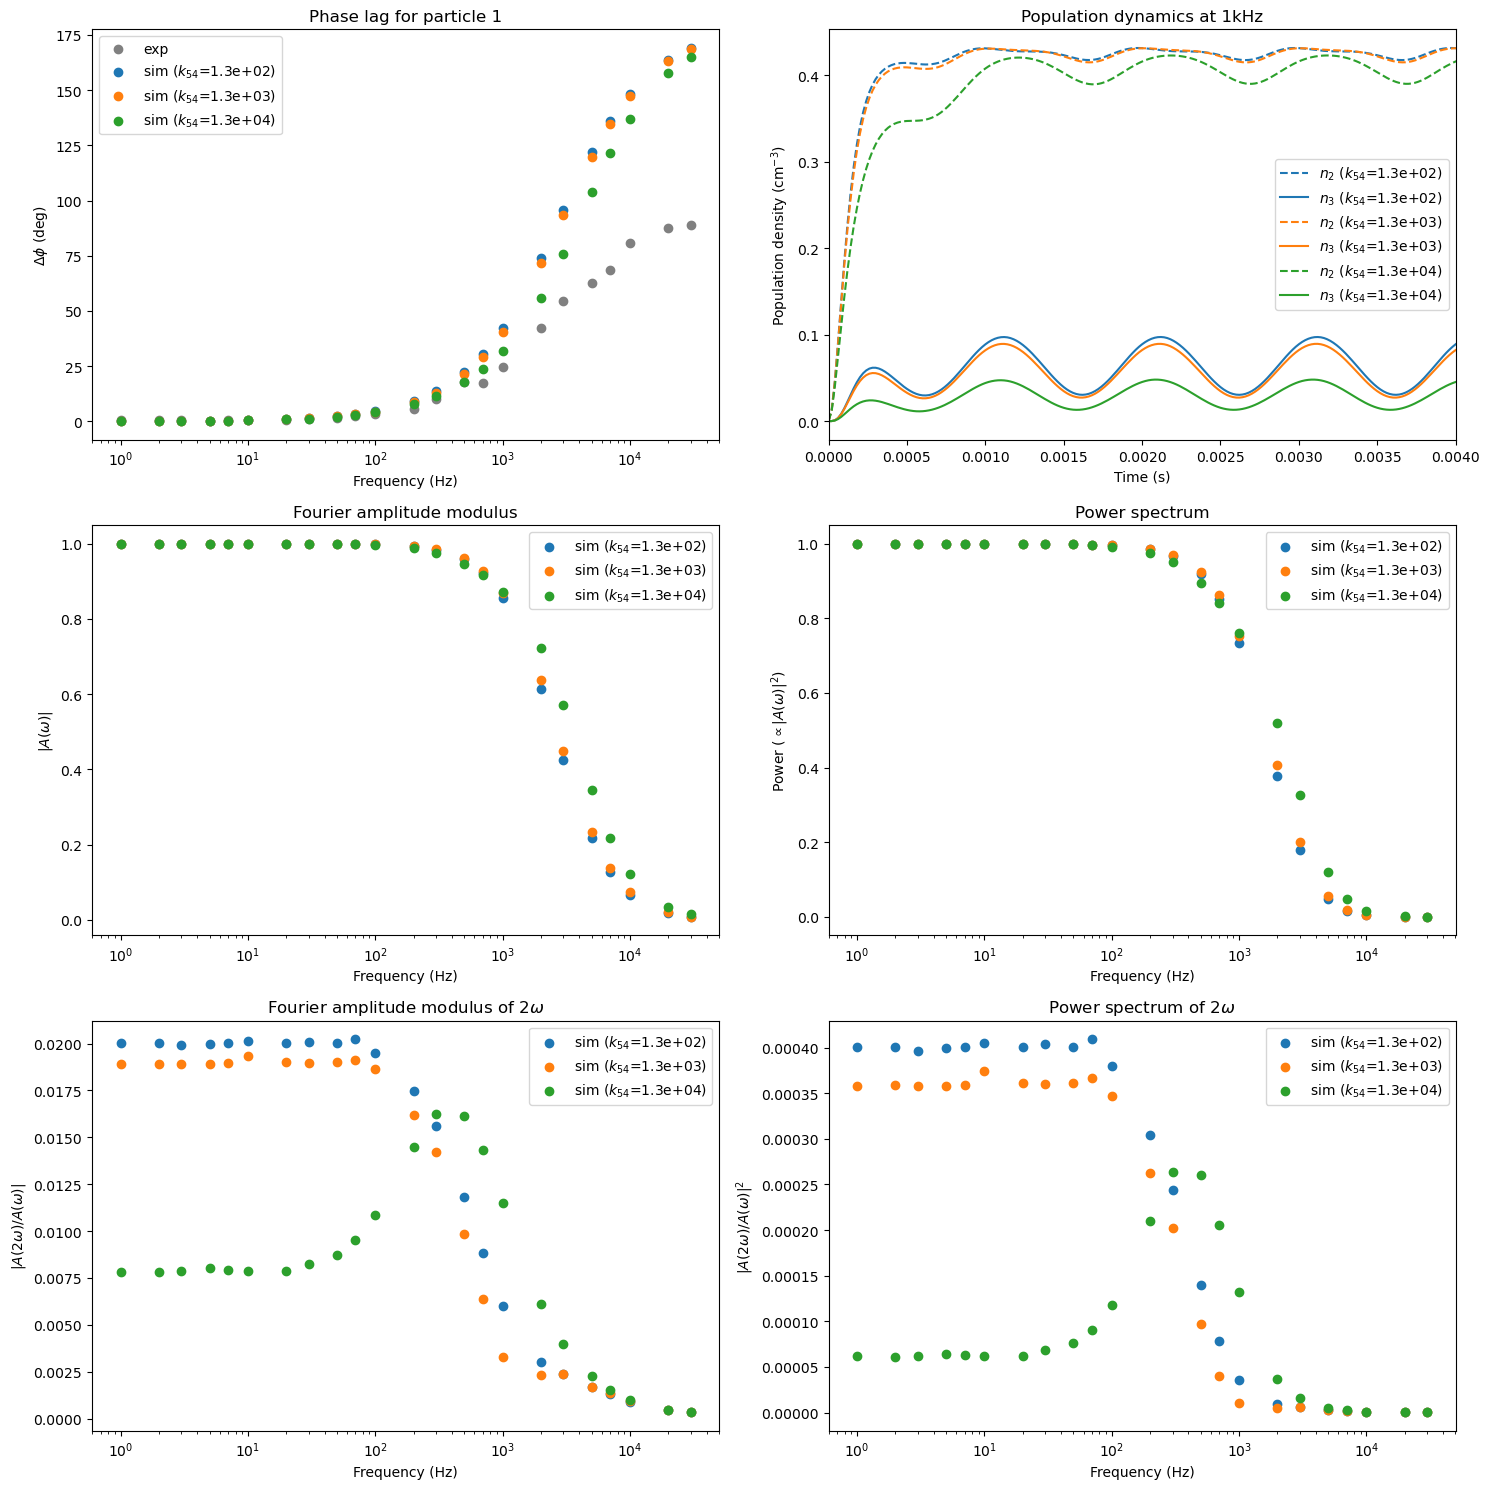

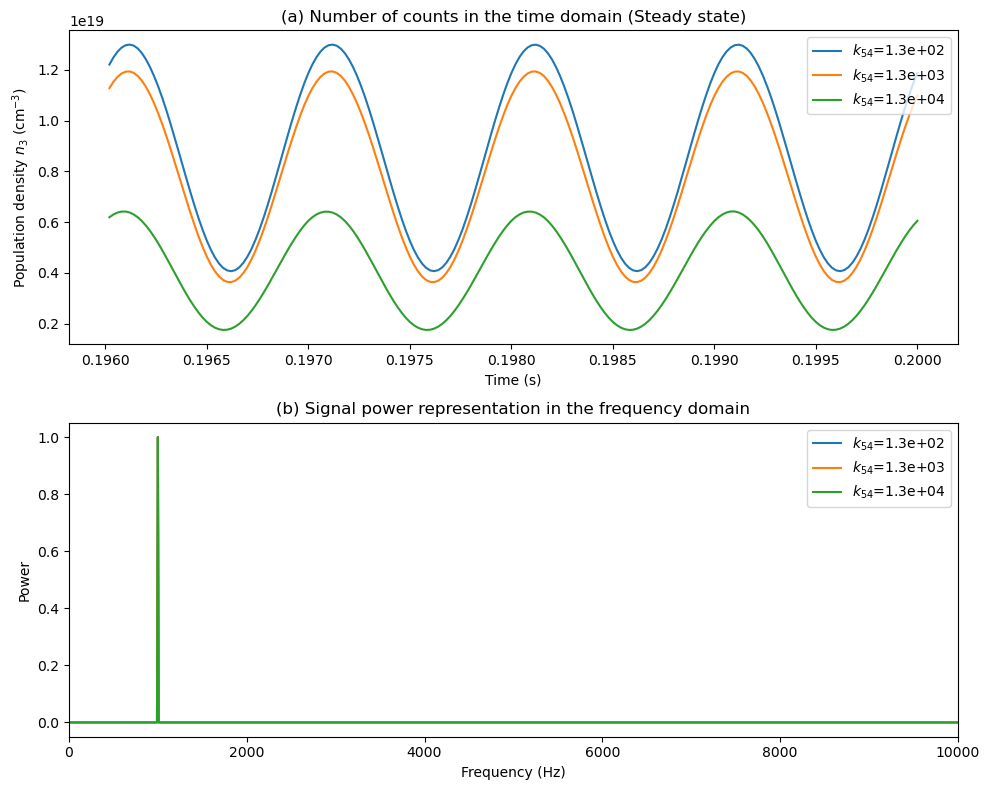

In [12]:
k21 = k21_initial
k31 = k31_initial
k54 = k54_initial
sigma = sigma_initial
ww51 = ww51_initial
ww52 = ww52_initial

params_k54 = [[ww51, ww52, k21, k31, k54*10**(i-1)] for i in range(3)] #Varia de 0.5, 1.0, 1.5

num_points = 23

fig, axs = plt.subplots(3, 2, figsize=(15, 15))

# ---> LISTA NOVA PARA ARMAZENAR OS DADOS DE 1kHz <---
dados_1kHz = []

for idx, param in enumerate(params_k54):
    # if iv_idx !=0: continue
    ww51, ww52, k21, k31, k54 = param
    print(f"k21 = {k21}")
    print(f"k31 = {k31}")
    print(f"k54 = {k54}")
    print(f"w51 = {ww51}")
    print(f"w52 = {ww52}")

    fases_calculadas = []

    for p_id, pd in enumerate(pd_list):
        if p_id != 0: continue
        frequencias_experimentais = pd[:num_points, 0] 
        fases_experimentais = pd[:num_points, 1] 
        W51, W52 = ww51, ww52
        sol_to_plot = []
        amps_list = []
        amps_list_2omega = []

        for f in frequencias_experimentais:
            # Simula 200 ciclos em tempo adimensional para garantir que o transiente morra
            t_span = (0, 200) 
            t_eval = np.linspace(t_span[0], t_span[1], 10000)
            sol = solve_ivp(
            odes, 
            t_span, 
            [n1_0/n0, 0, 0, n4_0/n0, 0], #x1 x2 x3 x4 x5 @ t=0
            t_eval=t_eval,
            args=(W51, W52, [k21, k31, k54], f), 
            method='Radau' # Mantendo o método Radau que demonstrou estabilidade acima
            )
            # Converte de volta para unidades físicas antes de extrair a fase
            n3 = (sol.y[2]) * n0 
            ts = (sol.t) * (1/f)
            n2 = (sol.y[1]) * n0 
            n11 = (sol.y[0]) * n0 

            if f == 1000:
                sol_to_plot = [ts, n11, n2, n3]
                # ---> SALVANDO SINAL PARA A NOVA FIGURA <---
                dados_1kHz.append((ts, n3, k54))

            fase_calc = extrair_fase(ts, n3, f)
            fases_calculadas.append(fase_calc)
            amps_list.append(get_fft_amp(ts, n3, f))
            amps_list_2omega.append(get_fft_amp(ts, n3, 2*f))

        fases_calculadas = np.unwrap(np.array(fases_calculadas))
        amps_list = np.array(amps_list)
        powers = amps_list**2

        amps_list_2omega = np.array(amps_list_2omega)

        amps_2omega_ad = [amps_list_2omega[i]/amps_list[i] for i in range(len(amps_list))]
        amps_2omega_ad = np.array(amps_2omega_ad)

        powers_2omega = amps_list_2omega**2
        powers_2omega_ad = amps_2omega_ad**2
        
        # Phase lag plot
        if idx == 0: 
            axs[0,0].scatter(frequencias_experimentais, adj_ph(fases_experimentais), color="gray", label="exp")
        axs[0,0].scatter(frequencias_experimentais, adj_ph(fases_calculadas), label=f"sim ($k_{{54}}$={k54:.1e})")
        axs[0,0].set_xscale("log")
        axs[0,0].set_ylabel("$\Delta \phi$ (deg)")
        axs[0,0].set_xlabel("Frequency (Hz)")
        axs[0,0].set_title("Phase lag for particle 1")

        # Population time evolution @ 1kHz
        ts, n11, n2, n3 = sol_to_plot
        linha, = axs[0,1].plot(ts, n2/n11.max(), linestyle="--",label=f"$n_2$ ($k_{{54}}$={k54:.1e})")
        axs[0,1].plot(ts, n3/n11.max(), color=linha.get_color(), label=f"$n_3$ ($k_{{54}}$={k54:.1e})")
        axs[0,1].set_ylabel("Population density (cm$^{-3}$)")
        axs[0,1].set_xlabel("Time (s)")
        axs[0,1].set_xlim([0,ts[int(len(ts)*(0.02))]])
        axs[0,1].set_title("Population dynamics at 1kHz")

        # Amplitudes plot
        axs[1,0].scatter(frequencias_experimentais, amps_list/amps_list.max(), label=f"sim ($k_{{54}}$={k54:.1e})")
        axs[1,0].set_ylabel("$|A(\omega)|$")
        axs[1,0].set_xlabel("Frequency (Hz)")
        axs[1,0].set_xscale("log")
        axs[1,0].set_title("Fourier amplitude modulus")

        # Power plot
        axs[1,1].scatter(frequencias_experimentais, powers/(powers).max(), label=f"sim ($k_{{54}}$={k54:.1e})")
        axs[1,1].set_ylabel("Power ($\propto |A(\omega)|^2$)")
        axs[1,1].set_xlabel("Frequency (Hz)")
        axs[1,1].set_xscale("log")
        axs[1,1].set_title("Power spectrum")

        # Amplitudes plot for 2omega
        axs[2,0].scatter(frequencias_experimentais, amps_2omega_ad, label=f"sim ($k_{{54}}$={k54:.1e})")
        axs[2,0].set_ylabel("$|A(2\omega)/A(\omega)|$")
        axs[2,0].set_xlabel("Frequency (Hz)")
        axs[2,0].set_xscale("log")
        axs[2,0].set_title("Fourier amplitude modulus of $2\omega$")

        # Power plot for 2omega
        axs[2,1].scatter(frequencias_experimentais, powers_2omega_ad, label=f"sim ($k_{{54}}$={k54:.1e})")
        axs[2,1].set_ylabel("$|A(2\omega)/A(\omega)|^2$")
        axs[2,1].set_xlabel("Frequency (Hz)")
        axs[2,1].set_xscale("log")
        axs[2,1].set_title("Power spectrum of $2\omega$")

axs[0,0].legend()
axs[0,1].legend()
axs[1,0].legend()
axs[1,1].legend()
axs[2,0].legend()
axs[2,1].legend()
fig.tight_layout()


# ---> CRIAÇÃO DA NOVA FIGURA PARA O ESPECTRO DE 1kHz <---
fig2, axs2 = plt.subplots(2, 1, figsize=(10, 8))

for ts_1k, n3_1k, k54_val in dados_1kHz:
    # 1. Domínio do tempo
    # Plotamos os últimos 4 ciclos (200 pontos no total, pois são 50 pts por ciclo)
    # Isso evita ver um bloco maciço de 200 ciclos e foca no regime estacionário
    axs2[0].plot(ts_1k[-200:], n3_1k[-200:], label=f"$k_{{54}}$={k54_val:.1e}")

    # 2. Domínio da frequência (Espectro de Potência)
    # Utilizamos a segunda metade do sinal para evitar vazamento espectral dos transientes
    meio = len(ts_1k) // 2
    ts_estacionario = ts_1k[meio:]
    n3_estacionario = n3_1k[meio:]
    
    N = len(ts_estacionario)
    dt = ts_estacionario[1] - ts_estacionario[0]
    
    yf = fft(n3_estacionario)
    xf = fftfreq(N, dt)
    
    # Filtro para pegar apenas frequências positivas (remove a componente DC em 0 Hz)
    idx_pos = xf > 0
    xf_pos = xf[idx_pos]
    power = np.abs(yf[idx_pos])**2
    
    axs2[1].plot(xf_pos, power/power.max(), label=f"$k_{{54}}$={k54_val:.1e}")

axs2[0].set_title("(a) Number of counts in the time domain (Steady state)")
axs2[0].set_xlabel("Time (s)")
axs2[0].set_ylabel("Population density $n_3$ (cm$^{-3}$)")
axs2[0].legend(loc="upper right")

axs2[1].set_title("(b) Signal power representation in the frequency domain")
axs2[1].set_xlabel("Frequency (Hz)")
axs2[1].set_ylabel("Power")
axs2[1].set_xlim([0, 10000]) # Foca nos harmônicos até 10kHz conforme sua imagem de referência
axs2[1].legend(loc="upper right")
fig2.tight_layout()

# O plt.show() agora vai renderizar ambas as janelas (fig e fig2)
plt.show()

### Varying sigma


k21 = 598.0
k31 = 23066.7
k54 = 1348.8
w51 = 1e-16
w52 = 1e-16
k21 = 598.0
k31 = 23066.7
k54 = 1348.8
w51 = 1e-16
w52 = 1e-16
k21 = 598.0
k31 = 23066.7
k54 = 1348.8
w51 = 1e-16
w52 = 1e-16


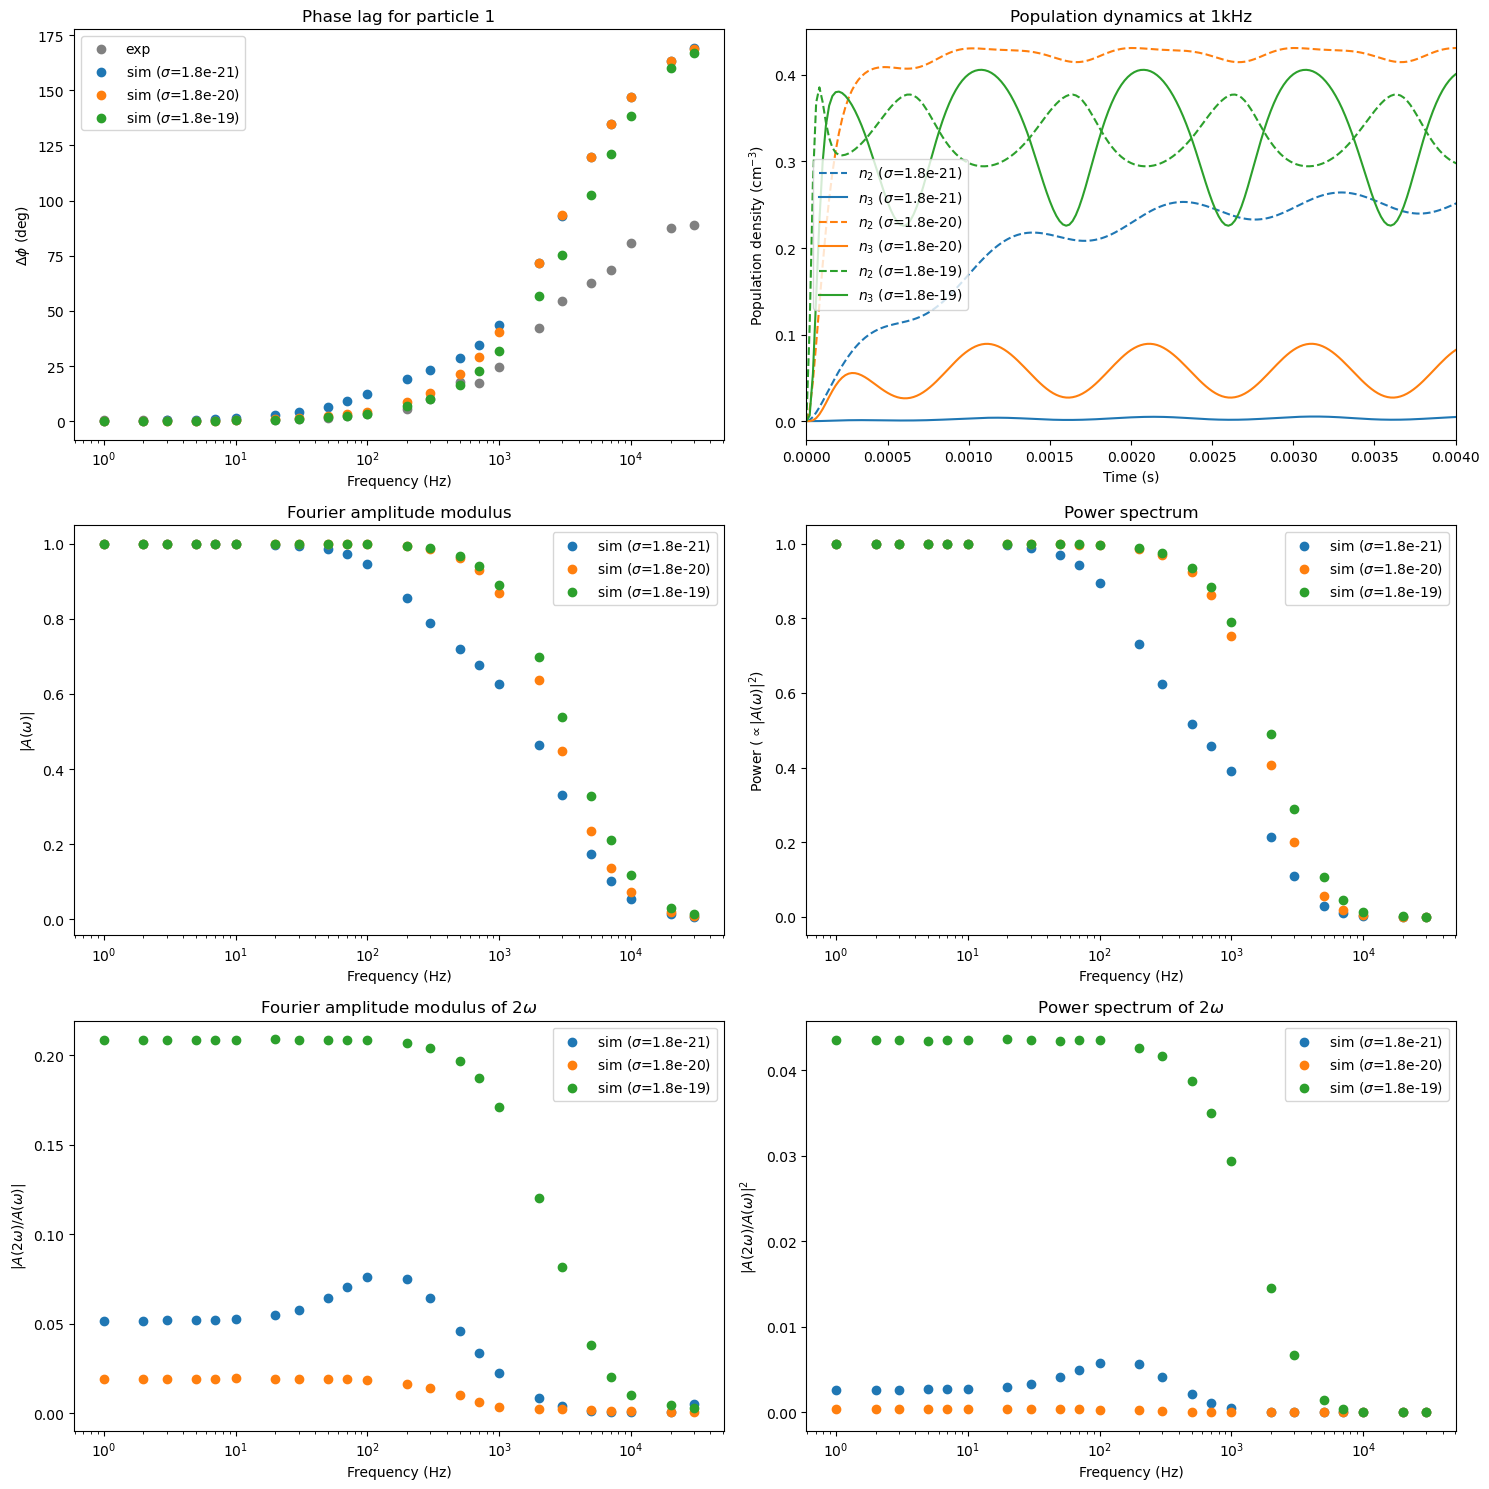

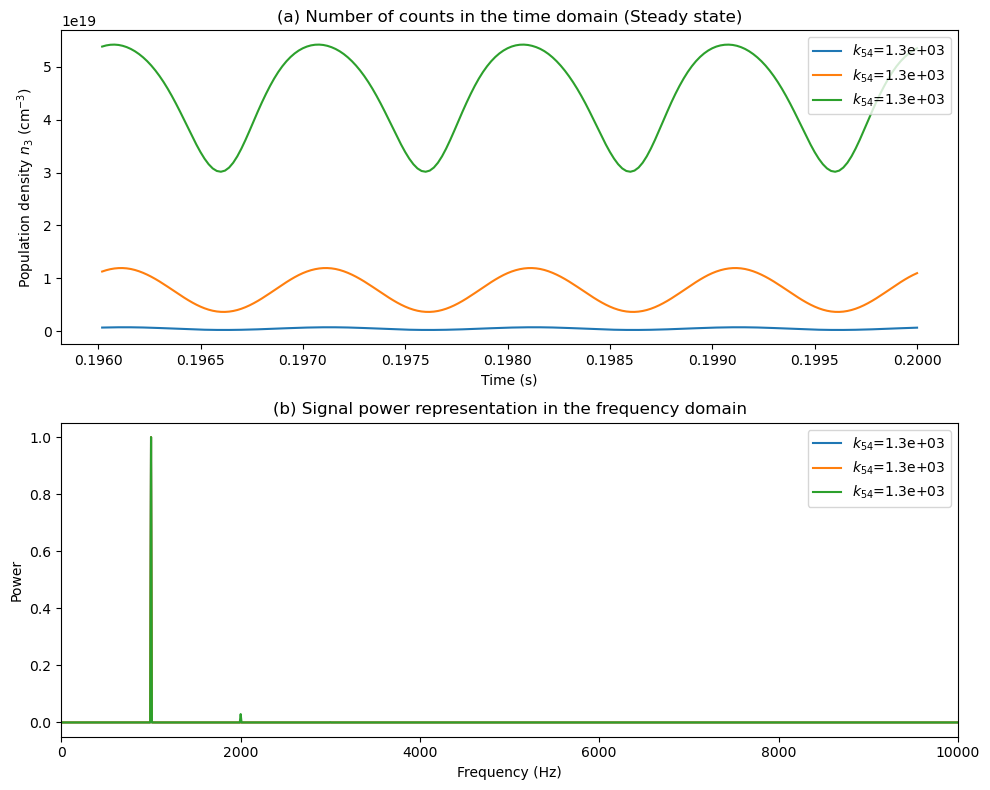

In [13]:
k21 = k21_initial
k31 = k31_initial
k54 = k54_initial
sigma = sigma_initial
ww51 = ww51_initial
ww52 = ww52_initial

params_sigma = [[ww51, ww52, k21, k31, k54, sigma*10**(i-1)] for i in range(3)] #Varia de 0.5, 1.0, 1.5

num_points = 23

fig, axs = plt.subplots(3, 2, figsize=(15, 15))

# ---> LISTA NOVA PARA ARMAZENAR OS DADOS DE 1kHz <---
dados_1kHz = []

def odes2(t, x, W51, W52, ks, sigma,freq):
    k21, k31, k54 = ks
    #Define new rates
    kpp21 = lambda f, k21: k21/f
    kpp31 = lambda f, k31: k31/f
    kpp54 = lambda f, k54: k54/f
    kp45 = lambda f: sigma*P/f
    wp51 = lambda f, W51: W51*n0/f
    wp52 = lambda f, W52: W52*n0/f


    # The 't' here represents the dimensionless variable tau (tau = t*f)
    x1, x2, x3, x4, x5 = x

    # Laser function according to previously defined settings
    F_t = offset + amplitude * np.cos(2 * np.pi * t)

    # Numerical safeguard: intensity cannot be negative.
    if F_t < 0: F_t = 0.0 

    # Yb3+ populations    
    dx5_dt = (kp45(freq) * F_t * x4 - wp51(freq, W51) * x5 * x1 
              - wp52(freq, W52) * x5 * x2 - kpp54(freq, k54) * x5)
    dx4_dt = -dx5_dt

    # Er3+ populations
    dx3_dt = wp52(freq, W52) * x5 * x2 - kpp31(freq, k31) * x3
    dx2_dt = wp51(freq, W51) * x5 * x1 - wp52(freq, W52) * x5 * x2 - kpp21(freq, k21) * x2 
    dx1_dt = -(dx3_dt + dx2_dt) 
    
    return [dx1_dt, dx2_dt, dx3_dt, dx4_dt, dx5_dt]

for idx, param in enumerate(params_sigma):
    # if iv_idx !=0: continue
    ww51, ww52, k21, k31, k54, sigma = param
    print(f"k21 = {k21}")
    print(f"k31 = {k31}")
    print(f"k54 = {k54}")
    print(f"w51 = {ww51}")
    print(f"w52 = {ww52}")

    fases_calculadas = []

    for p_id, pd in enumerate(pd_list):
        if p_id != 0: continue
        frequencias_experimentais = pd[:num_points, 0] 
        fases_experimentais = pd[:num_points, 1] 
        W51, W52 = ww51, ww52
        sol_to_plot = []
        amps_list = []
        amps_list_2omega = []

        for f in frequencias_experimentais:
            # Simula 200 ciclos em tempo adimensional para garantir que o transiente morra
            t_span = (0, 200) 
            t_eval = np.linspace(t_span[0], t_span[1], 10000)
            sol = solve_ivp(
            odes2, 
            t_span, 
            [n1_0/n0, 0, 0, n4_0/n0, 0], #x1 x2 x3 x4 x5 @ t=0
            t_eval=t_eval,
            args=(W51, W52, [k21, k31, k54], sigma, f), 
            method='Radau' # Mantendo o método Radau que demonstrou estabilidade acima
            )
            # Converte de volta para unidades físicas antes de extrair a fase
            n3 = (sol.y[2]) * n0 
            ts = (sol.t) * (1/f)
            n2 = (sol.y[1]) * n0 
            n11 = (sol.y[0]) * n0 

            if f == 1000:
                sol_to_plot = [ts, n11, n2, n3]
                # ---> SALVANDO SINAL PARA A NOVA FIGURA <---
                dados_1kHz.append((ts, n3, k54))

            fase_calc = extrair_fase(ts, n3, f)
            fases_calculadas.append(fase_calc)
            amps_list.append(get_fft_amp(ts, n3, f))
            amps_list_2omega.append(get_fft_amp(ts, n3, 2*f))

        fases_calculadas = np.unwrap(np.array(fases_calculadas))
        amps_list = np.array(amps_list)
        powers = amps_list**2

        amps_list_2omega = np.array(amps_list_2omega)

        amps_2omega_ad = [amps_list_2omega[i]/amps_list[i] for i in range(len(amps_list))]
        amps_2omega_ad = np.array(amps_2omega_ad)

        powers_2omega = amps_list_2omega**2
        powers_2omega_ad = amps_2omega_ad**2
        
        # Phase lag plot
        if idx == 0: 
            axs[0,0].scatter(frequencias_experimentais, adj_ph(fases_experimentais), color="gray", label="exp")
        axs[0,0].scatter(frequencias_experimentais, adj_ph(fases_calculadas), label=f"sim ($\sigma$={sigma:.1e})")
        axs[0,0].set_xscale("log")
        axs[0,0].set_ylabel("$\Delta \phi$ (deg)")
        axs[0,0].set_xlabel("Frequency (Hz)")
        axs[0,0].set_title("Phase lag for particle 1")

        # Population time evolution @ 1kHz
        ts, n11, n2, n3 = sol_to_plot
        linha, = axs[0,1].plot(ts, n2/n11.max(), linestyle="--",label=f"$n_2$ ($\sigma$={sigma:.1e})")
        axs[0,1].plot(ts, n3/n11.max(), color=linha.get_color(), label=f"$n_3$ ($\sigma$={sigma:.1e})")
        axs[0,1].set_ylabel("Population density (cm$^{-3}$)")
        axs[0,1].set_xlabel("Time (s)")
        axs[0,1].set_xlim([0,ts[int(len(ts)*(0.02))]])
        axs[0,1].set_title("Population dynamics at 1kHz")

        # Amplitudes plot
        axs[1,0].scatter(frequencias_experimentais, amps_list/amps_list.max(), label=f"sim ($\sigma$={sigma:.1e})")
        axs[1,0].set_ylabel("$|A(\omega)|$")
        axs[1,0].set_xlabel("Frequency (Hz)")
        axs[1,0].set_xscale("log")
        axs[1,0].set_title("Fourier amplitude modulus")

        # Power plot
        axs[1,1].scatter(frequencias_experimentais, powers/(powers).max(), label=f"sim ($\sigma$={sigma:.1e})")
        axs[1,1].set_ylabel("Power ($\propto |A(\omega)|^2$)")
        axs[1,1].set_xlabel("Frequency (Hz)")
        axs[1,1].set_xscale("log")
        axs[1,1].set_title("Power spectrum")

        # Amplitudes plot for 2omega
        axs[2,0].scatter(frequencias_experimentais, amps_2omega_ad, label=f"sim ($\sigma$={sigma:.1e})")
        axs[2,0].set_ylabel("$|A(2\omega)/A(\omega)|$")
        axs[2,0].set_xlabel("Frequency (Hz)")
        axs[2,0].set_xscale("log")
        axs[2,0].set_title("Fourier amplitude modulus of $2\omega$")

        # Power plot for 2omega
        axs[2,1].scatter(frequencias_experimentais, powers_2omega_ad, label=f"sim ($\sigma$={sigma:.1e})")
        axs[2,1].set_ylabel("$|A(2\omega)/A(\omega)|^2$")
        axs[2,1].set_xlabel("Frequency (Hz)")
        axs[2,1].set_xscale("log")
        axs[2,1].set_title("Power spectrum of $2\omega$")

axs[0,0].legend()
axs[0,1].legend()
axs[1,0].legend()
axs[1,1].legend()
axs[2,0].legend()
axs[2,1].legend()
fig.tight_layout()


# ---> CRIAÇÃO DA NOVA FIGURA PARA O ESPECTRO DE 1kHz <---
fig2, axs2 = plt.subplots(2, 1, figsize=(10, 8))

for ts_1k, n3_1k, k54_val in dados_1kHz:
    # 1. Domínio do tempo
    # Plotamos os últimos 4 ciclos (200 pontos no total, pois são 50 pts por ciclo)
    # Isso evita ver um bloco maciço de 200 ciclos e foca no regime estacionário
    axs2[0].plot(ts_1k[-200:], n3_1k[-200:], label=f"$k_{{54}}$={k54_val:.1e}")

    # 2. Domínio da frequência (Espectro de Potência)
    # Utilizamos a segunda metade do sinal para evitar vazamento espectral dos transientes
    meio = len(ts_1k) // 2
    ts_estacionario = ts_1k[meio:]
    n3_estacionario = n3_1k[meio:]
    
    N = len(ts_estacionario)
    dt = ts_estacionario[1] - ts_estacionario[0]
    
    yf = fft(n3_estacionario)
    xf = fftfreq(N, dt)
    
    # Filtro para pegar apenas frequências positivas (remove a componente DC em 0 Hz)
    idx_pos = xf > 0
    xf_pos = xf[idx_pos]
    power = np.abs(yf[idx_pos])**2
    
    axs2[1].plot(xf_pos, power/power.max(), label=f"$k_{{54}}$={k54_val:.1e}")

axs2[0].set_title("(a) Number of counts in the time domain (Steady state)")
axs2[0].set_xlabel("Time (s)")
axs2[0].set_ylabel("Population density $n_3$ (cm$^{-3}$)")
axs2[0].legend(loc="upper right")

axs2[1].set_title("(b) Signal power representation in the frequency domain")
axs2[1].set_xlabel("Frequency (Hz)")
axs2[1].set_ylabel("Power")
axs2[1].set_xlim([0, 10000]) # Foca nos harmônicos até 10kHz conforme sua imagem de referência
axs2[1].legend(loc="upper right")
fig2.tight_layout()

# O plt.show() agora vai renderizar ambas as janelas (fig e fig2)
plt.show()